# LangChain - LangGraph 에이전트 성능 최적화: 비동기 및 병렬 처리

## 개요

LangChain & LangGraph를 활용한 에이전트 시스템에서  
**비동기(Async) 및 병렬(Parallel) 처리**를 통해 **성능을 최적화**하는 방법을 다룹니다.

### 학습 목표

1. Python의 비동기 프로그래밍 개념과 asyncio 활용법 이해
2. LangChain/LangGraph의 비동기 API 활용 방법 습득
3. 에이전트의 병렬 실행 전략 구현
4. 동기/비동기, 순차/병렬 실행의 성능 차이 분석
5. 프로덕션 환경을 위한 Best Practices 습득

In [5]:
"""필수 패키지 설치."""
%pip install -qU \
    langchain \
    langchain-openai \
    langgraph \
    numpy \
    psutil \
    yappi \
    tenacity

Note: you may need to restart the kernel to use updated packages.


## 1. 환경 설정 및 의존성 설치

In [6]:
"""환경 변수 설정 및 필요한 라이브러리 임포트.
OpenAI API 키가 환경 변수로 설정되어 있는지 확인합니다.
"""

import asyncio
import os
import time
from typing import Annotated, List, Dict, Any

# LangChain 관련 임포트
from langchain.agents import create_agent
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool, ToolRuntime
from langchain_core.runnables import RunnableConfig

# Models
from langchain_openai import ChatOpenAI

# LangGraph 관련 임포트
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
load_dotenv()


True

## 2. 비동기 프로그래밍 기초

### 2.1 동기 vs 비동기 처리

#### 동기(Synchronous) 처리

작업이 순차적으로 실행되며, 하나의 작업이 완료될 때까지 다음 작업이 대기합니다.

```
작업1 시작 → 작업1 완료 → 작업2 시작 → 작업2 완료 → 작업3 시작 → 작업3 완료
```

#### 비동기(Asynchronous) 처리

작업이 완료되기를 기다리지 않고 다른 작업을 동시에 진행할 수 있습니다.  
`I/O 바운드 작업(네트워크 요청, 파일 읽기/쓰기 등)`에 특히 유용합니다.

```
작업1 시작 ──┐
작업2 시작 ──┼→ 동시 실행
작업3 시작 ──┘
```

### 2.2 비동기 처리가 필요한 이유

LLM 에이전트는 다음과 같은 I/O 바운드 작업을 수행합니다:

1. **LLM API 호출**: 네트워크를 통해 원격 서버와 통신
2. **도구 실행**: 외부 API 호출, 데이터베이스 쿼리 등
3. **벡터 데이터베이스 검색**: 임베딩 계산 및 유사도 검색

이러한 작업들은 CPU가 아닌 I/O 완료를 대기하는 시간이 대부분이므로,  
비동기 처리를 통해 대기 시간 동안 다른 작업을 수행하여 전체 실행 시간을 크게 단축할 수 있습니다.

### 2.3 Python asyncio 기본 예제

비동기 함수 정의와 실행 방법을 학습합니다.


In [ ]:
"""동기 vs 비동기 실행 시간 비교.

이 예제는 네트워크 요청과 유사한 지연 시간을 시뮬레이션하여
동기와 비동기 실행의 성능 차이를 보여줍니다.
"""

def sync_task(name: str, delay: float) -> str:
    """동기 방식으로 작업을 수행하는 함수.

    Args:
        name: 작업 이름
        delay: 지연 시간(초)

    Returns:
        작업 완료 메시지
    """
    print(f"[동기] {name} 시작")
    time.sleep(delay)  # CPU를 블로킹하는 동기 대기
    print(f"[동기] {name} 완료")
    return f"{name} 결과"


async def async_task(name: str, delay: float) -> str:
    """비동기 방식으로 작업을 수행하는 함수.

    Args:
        name: 작업 이름
        delay: 지연 시간(초)

    Returns:
        작업 완료 메시지
    """
    print(f"[비동기] {name} 시작")
    await asyncio.sleep(delay)  # NOTE: 이벤트 루프를 블로킹하지 않는 비동기 대기
    print(f"[비동기] {name} 완료")
    return f"{name} 결과"


# 동기 실행: 순차적으로 실행
print("=== 동기 실행 ===")
start_time = time.time()
sync_task("작업1", 1.0)
sync_task("작업2", 1.0)
sync_task("작업3", 1.0)
sync_duration = time.time() - start_time
print(f"동기 실행 시간: {sync_duration:.2f}초\n")


# 비동기 실행: 동시에 실행
async def run_async_tasks():
    """여러 비동기 작업을 동시에 실행하는 함수."""
    print("=== 비동기 실행 ===")
    start_time = time.time()

    # asyncio.gather를 사용하여 여러 작업을 동시에 실행
    results = await asyncio.gather(
        async_task("작업1", 1.0),
        async_task("작업2", 1.0),
        async_task("작업3", 1.0),
    )

    async_duration = time.time() - start_time
    print(f"비동기 실행 시간: {async_duration:.2f}초")
    print(f"성능 향상: {sync_duration / async_duration:.2f}배")
    return results


# Jupyter 환경에서 비동기 함수 실행
results = await run_async_tasks()

=== 동기 실행 ===
[동기] 작업1 시작
[동기] 작업1 완료
[동기] 작업2 시작
[동기] 작업2 완료
[동기] 작업3 시작
[동기] 작업3 완료
동기 실행 시간: 3.01초

=== 비동기 실행 ===
[비동기] 작업1 시작
[비동기] 작업2 시작
[비동기] 작업3 시작
[비동기] 작업1 완료
[비동기] 작업2 완료
[비동기] 작업3 완료
비동기 실행 시간: 1.00초
성능 향상: 3.00배


## Event Loop

파이썬의 비동기 환경 -> [이벤트/루프] <- 작업을 요청함 

1. 이벤트 루프란 무엇인가

  이벤트 루프는 "할 일 목록을 들고 돌아가는 단 하나의 일꾼(단일 스레드)" 입니다.

  머릿속에 이런 그림을 그려보세요. 식당에 웨이터가 딱 한 명 있습니다. 이 웨이터가 이벤트 루프예요. 그리고 코루틴들은 손님 테이블입니다.

  이 웨이터(이벤트 루프)가 하는 일은 무한 반복문입니다:

  while True:
      1. 지금 실행할 준비가 된 작업이 있나? → 있으면 실행
      2. 그 작업이 "나 잠깐 기다려야 해(await)" 라고 하면? → 옆으로 치워두고
      3. 다음으로 준비된 작업을 실행
      4. 아까 치워둔 작업의 대기가 끝났나? → 끝났으면 다시 줄 세움
      5. 반복

  핵심은 일꾼이 한 명뿐이라는 것입니다. 그래서 "동시에 여러 개"가 진짜 물리적 동시 실행이 아니라, 한 명이 빠르게 번갈아 처리하는 것입니다.

  2. "블로킹한다"는 것의 의미

  블로킹 = 웨이터(일꾼)를 한 작업이 독점해서 다른 일을 못 하게 막는 것.

  웨이터가 한 테이블의 주문 요리가 다 나올 때까지 주방 앞에 멍하니 서서 기다린다면? 그동안 다른 테이블 10개는 물 한 잔도 못 받습니다. 이게 블로킹입니다.

  코드로 보면:

  import time

  def cook():
      time.sleep(3)   # ❌ 블로킹! 일꾼이 3초간 완전히 멈춤
      return "요리 완성"

  time.sleep(3)은 일꾼 자체를 3초간 마비시킵니다. 이 3초 동안 이벤트 루프는 다른 어떤 코루틴도 실행하지 못합니다. 손님이 아무리 많아도 전부 멈춰 있어요.

  3. "await는 블로킹하지 않는다"의 진짜 의미

  이제 핵심입니다. await는 똑같이 "기다린다"인데 왜 블로킹이 아닐까요?

  import asyncio

  async def cook():
      await asyncio.sleep(3)   # ✅ 논블로킹! "3초 뒤에 깨워줘" 하고 일꾼을 풀어줌
      return "요리 완성"

  차이는 이겁니다:

  ┌───────────────┬─────────────────────────┬───────────────────────────────────────┐
  │               │      time.sleep(3)      │        await asyncio.sleep(3)         │
  ├───────────────┼─────────────────────────┼───────────────────────────────────────┤
  │ 의미          │ 일꾼이 직접 3초 서 있음 │ "3초 뒤 깨워줘" 메모 남기고 자리 비움 │
  ├───────────────┼─────────────────────────┼───────────────────────────────────────┤
  │ 그동안 일꾼은 │ 아무것도 못 함          │ 다른 작업 처리하러 감                 │
  └───────────────┴─────────────────────────┴───────────────────────────────────────┘

  await를 만나는 순간, 코루틴은 이벤트 루프에게 이렇게 말합니다:

  ▎ "나 지금 I/O 기다려야 하니까, 제어권을 너에게 돌려줄게(yield). 기다리는 동안 다른 일 하고 있어. 내 대기가 끝나면 그때 나를 다시 불러줘."

  이 "제어권을 돌려준다(yield)" 가 논블로킹의 본질입니다. 일꾼은 손을 놓고 멍하니 기다리는 게 아니라, 그 시간에 다른 테이블을 처리하러 갑니다.

  4. 한눈에 보는 비교

  # ❌ 블로킹 버전 — 총 9초
  async def main():
      await blocking_cook()  # 3초 (일꾼 멈춤)
      await blocking_cook()  # 3초
      await blocking_cook()  # 3초

  # ✅ 논블로킹 버전 — 총 3초
  async def main():
      await asyncio.gather(
          cook(),  # ┐
          cook(),  # ├ 세 개가 "동시에" 대기에 들어감
          cook(),  # ┘ 일꾼은 대기 시간 동안 셋을 번갈아 챙김
      )

  논블로킹 버전이 3초인 이유: 첫 번째 cook이 await asyncio.sleep(3)에서 자리를 비우는 순간, 일꾼이 곧바로 두 번째, 세 번째 cook을 출발시킵니다. 세 개의 "3초 타이머"가 겹쳐서 흐르니까 전체가  
  3초입니다.

  5. 가장 중요한 함정 ⚠️

  async def 함수 안이라고 무조건 논블로킹이 아닙니다. 그 안에서 블로킹 함수를 쓰면 이벤트 루프 전체가 멈춥니다.

  async def bad():
      time.sleep(3)        # ❌ async 함수 안이어도 일꾼을 마비시킴!

  async def good():
      await asyncio.sleep(3)  # ✅ 제대로 양보함

  규칙: 이벤트 루프 위에서는 반드시 await가 붙는 비동기 라이브러리를 써야 합니다. (requests 대신 aiohttp, time.sleep 대신 asyncio.sleep, 일반 DB 드라이버 대신 async 드라이버 등.) 어쩔 수 없이
  블로킹 코드를 써야 하면 loop.run_in_executor로 별도 스레드에 넘깁니다.

  한 줄 요약

  - 이벤트 루프 = 준비된 코루틴들을 번갈아 실행하는 단 하나의 일꾼.
  - 블로킹 = 한 작업이 그 일꾼을 독점해 멈춰 세우는 것.
  - await가 논블로킹인 이유 = 기다려야 할 때 일꾼을 붙잡지 않고 제어권을 돌려줘서(yield), 그 시간에 일꾼이 다른 코루틴을 처리하게 하기 때문.

### 2.4 주요 asyncio 개념

#### async/await 키워드

- **async def**: 비동기 함수(코루틴)를 정의합니다.
- **await**: 비동기 작업이 완료될 때까지 대기하지만, 이벤트 루프를 블로킹하지 않습니다.

#### asyncio.gather()

여러 비동기 작업을 동시에 실행하고 모든 결과를 수집합니다.

```python
results = await asyncio.gather(
    task1(),
    task2(),
    task3(),
)
```

#### asyncio.create_task()

코루틴을 태스크로 래핑하여 백그라운드에서 실행합니다.

```python
task = asyncio.create_task(some_coroutine())
result = await task
```

● asyncio.create_task()의 "백그라운드 실행"이 가지는 의미를 정리해 드릴게요.

  핵심: "코루틴을 만드는 것"과 "실행하는 것"은 다르다

  some_coroutine()        # ← 아직 실행 안 됨. 코루틴 객체만 생성
  await some_coroutine()  # ← 여기서 실행되고, 끝날 때까지 기다림
  
  코루틴은 그냥 호출하면 실행되지 않습니다. await를 만나야 실행됩니다. 그런데 await는 "끝날 때까지 멈춰서 기다린다"는 뜻이라 그 자리에서 블로킹됩니다.

  create_task()는 이 둘 사이의 제3의 길입니다. 지금 실행을 예약(스케줄링)하되, 기다리지는 않는다.

  task = asyncio.create_task(some_coroutine())  # 이벤트 루프에 등록 → 실행 시작
  # ↑ 이 줄을 지나가도 some_coroutine은 계속 돌고 있음
  # 그 사이 다른 코드를 실행할 수 있음
  result = await task                            # 필요해지면 그때 결과를 회수

  "백그라운드"의 의미

  여기서 백그라운드는 별도 스레드/프로세스가 아닙니다. 같은 단일 스레드, 같은 이벤트 루프 안에서 돌아갑니다. 정확히는:

  ▎ "내가 await로 멈춰 있는(I/O 대기 등) 틈에, 이벤트 루프가 등록된 task를 끼워서 실행시킨다"

  즉 양보(yield) 지점이 있어야 동시성이 생깁니다. CPU만 빡세게 쓰는 동기 코드는 task로 만들어도 백그라운드 실행이 안 됩니다 (양보할 틈이 없으니까).

  create_task vs gather 비교

  # gather: 등록과 동시에 "전부 끝날 때까지" 기다림 (한 지점에 묶임)
  results = await asyncio.gather(task1(), task2(), task3())

  # create_task: 먼저 띄워놓고, 내 일을 하다가, 원할 때 회수
  t1 = asyncio.create_task(task1())
  t2 = asyncio.create_task(task2())

  do_something_else()   # ← task들이 도는 동안 다른 작업 가능

  r1 = await t1         # 필요한 순간에 결과 수령
  r2 = await t2

  실질적으로 얻는 것

  1. 선(先)실행 — await로 회수하기 전에 이미 일이 진행됨. 두 작업을 진짜로 겹쳐서 실행시킬 수 있음.

  # ❌ 순차 (총 2초)
  a = await fetch_a()   # 1초 기다리고
  b = await fetch_b()   # 또 1초 기다림

  # ✅ 동시 (총 1초)
  ta = asyncio.create_task(fetch_a())  # 둘 다 동시에 출발
  tb = asyncio.create_task(fetch_b())
  a = await ta
  b = await tb

  2. 유연한 제어 — task 객체를 들고 있으니 .cancel()로 취소하거나, 상태(.done())를 확인하거나, 다른 task와 조합(asyncio.wait, as_completed)할 수 있습니다.
  3. fire-and-forget 패턴 — 결과를 굳이 기다릴 필요 없는 작업(로그 전송, 알림 등)을 띄워두고 메인 흐름을 계속 진행.

  한 줄 요약

  create_task()의 백그라운드 실행 = 별도 스레드가 아니라, 단일 이벤트 루프가 await 대기 시간을 활용해 여러 코루틴을 번갈아 진행시키는 동시성. "지금 실행은 시작하되 회수는 나중에" 하는 분리가 
  핵심입니다.

  ▎ ⚠️ 주의: create_task로 만든 task의 참조(t1)를 변수로 잡아두지 않으면 가비지 컬렉션으로 사라질 수 있습니다. 또 task 안에서 발생한 예외는 await하기 전까지 드러나지 않으니 주의하세요.       

  궁금하시면 실제 예제 코드를 만들어 실행 시간을 비교해 보여드릴 수도 있습니다.

In [8]:
import asyncio
import time
from typing import List

# 예제 1: asyncio.gather() - 여러 작업 동시 실행
async def fetch_data(source: str, delay: float) -> str:
    """데이터 페칭 시뮬레이션"""
    print(f"⏳ Fetching from {source}...")
    await asyncio.sleep(delay)
    print(f"  {source} complete")
    return f"Data from {source}"

async def demo_gather():
    """asyncio.gather()로 병렬 실행"""
    print("\n=== asyncio.gather() Demo ===")
    start = time.time()

    # 3개 작업을 동시에 실행
    results = await asyncio.gather(
        fetch_data("API-1", 2.0),
        fetch_data("API-2", 1.5),
        fetch_data("API-3", 1.0),
    )

    elapsed = time.time() - start
    print(f"\nTotal time: {elapsed:.2f}s (not 4.5s!)")
    print(f"Results: {results}")

    return results

# 예제 2: asyncio.create_task() - 백그라운드 실행
async def long_running_operation() -> str:
    """오래 걸리는 작업"""
    print("  Long operation started...")
    await asyncio.sleep(3)
    print("  Long operation complete")
    return "Operation result"

async def demo_create_task():
    """asyncio.create_task()로 백그라운드 실행"""
    print("\n=== asyncio.create_task() Demo ===")
    start = time.time()

    # 백그라운드에서 시작
    task = asyncio.create_task(long_running_operation())

    # 다른 작업 수행 가능
    print("  Doing other work...")
    await asyncio.sleep(1)
    print("  Other work done")

    # 백그라운드 작업 결과 대기
    result = await task

    elapsed = time.time() - start
    print(f"\nTotal time: {elapsed:.2f}s")
    print(f"Result: {result}")

    return result

# 예제 3: asyncio.wait_for() - 타임아웃
async def slow_operation() -> str:
    await asyncio.sleep(5) # NOTE: 꼭 asyncio.sleep 사용 (time.sleep는 블로킹!!)
    return "Done"

async def demo_timeout():
    """asyncio.wait_for()로 타임아웃 설정"""
    print("\n=== asyncio.wait_for() Demo ===")

    try:
        result = await asyncio.wait_for(
            slow_operation(),
            timeout=2.0  # 2초 제한
        )
        print(f"Result: {result}")
    except asyncio.TimeoutError:
        print("Operation timed out!")

async def run_all_demos():
    await demo_gather()
    await demo_create_task()
    await demo_timeout()

await run_all_demos()


=== asyncio.gather() Demo ===
⏳ Fetching from API-1...
⏳ Fetching from API-2...
⏳ Fetching from API-3...
  API-3 complete
  API-2 complete
  API-1 complete

Total time: 2.00s (not 4.5s!)
Results: ['Data from API-1', 'Data from API-2', 'Data from API-3']

=== asyncio.create_task() Demo ===
  Doing other work...
  Long operation started...
  Other work done
  Long operation complete

Total time: 3.00s
Result: Operation result

=== asyncio.wait_for() Demo ===
Operation timed out!


### 2.5 Python의 동시성 모델: 비동기 vs 병렬 vs 동시 실행

Python에서는 동시성을 구현하는 여러 방법이 있으며, 각각 적합한 사용 사례가 다릅니다.

#### I/O Bound vs CPU Bound 작업

작업 유형에 따라 적절한 동시성 모델이 달라집니다.

**I/O Bound 작업**
- 네트워크 요청, 파일 읽기/쓰기, 데이터베이스 쿼리 등
- CPU는 유휴 상태이고 I/O 완료를 대기
- **해결책**: asyncio (비동기)

**CPU Bound 작업**
- 복잡한 수학 계산, 이미지 처리, 데이터 분석 등
- CPU를 집중적으로 사용
- **해결책**: multiprocessing (병렬)

#### 세 가지 동시성 접근법 비교

| 모델 | 라이브러리 | 적합한 작업 | 장점 | 단점 |
|------|-----------|------------|------|------|
| **비동기** | asyncio | I/O bound | 메모리 효율적, 수천 개의 동시 작업 | 코드 복잡도 증가, 라이브러리 지원 필요 |
| **멀티스레딩** | threading | I/O bound (블로킹) | 기존 동기 라이브러리 사용 가능 | GIL로 인해 CPU bound에 비효율적 |
| **멀티프로세싱** | multiprocessing | CPU bound | 진정한 병렬 실행, GIL 우회 | 메모리 오버헤드, 프로세스 간 통신 비용 |

#### GIL (Global Interpreter Lock)

Python의 CPython 인터프리터는 GIL이라는 뮤텍스를 사용하여 한 번에 하나의 스레드만 Python 바이트코드를 실행하도록 제한합니다. 

- **멀티스레딩**: CPU bound 작업에서는 성능 향상이 없음
- **비동기**: 단일 스레드에서 동작하므로 GIL 영향 없음
- **멀티프로세싱**: 각 프로세스가 독립적인 인터프리터를 가지므로 GIL 우회

> 참고로 Python 3.14 에서 GIL 제거된 Free Thread Python 의 첫번째 버전이 출시되었습니다.
(https://news.hada.io/topic?id=23514)

**LLM 에이전트의 경우**: 대부분 I/O bound 작업(API 호출, 벡터 검색)이므로 **asyncio가 최적**입니다.


문제 예시
- asnyc 작업을 할 때 sql alchemy 와 같은 동기 방식의 driver를 사용하면 blocking이 생김(여러개 호출하면 이벤트 루프 멈춤)

### 이벤트 루프 블로킹 문제와 해결

비동기 코드에서 블로킹 작업을 실행하면 **이벤트 루프가 멈춰** 전체 애플리케이션이 정지합니다.

#### 흔한 실수들

**1. 동기 함수를 비동기 컨텍스트에서 호출**
```python
#   잘못된 예
async def bad_example():
    time.sleep(5)  # 이벤트 루프 블로킹!
    return "done"
```

**2. 블로킹 라이브러리 사용**
```python
#   requests는 동기 라이브러리
import requests
async def bad_fetch():
    response = requests.get(url)  # 블로킹!
```

**3. CPU 집약적 작업**
```python
#   무거운 계산이 이벤트 루프 차단
async def bad_compute():
    result = expensive_computation()  # CPU bound!
```

#### 해결 방법

| 문제 | 해결책 | 예제 |
|------|--------|------|
| 동기 sleep | `asyncio.sleep()` | `await asyncio.sleep(5)` |
| 블로킹 I/O | 비동기 라이브러리 사용 | `requests` 대신 `aiohttp` |
| CPU 작업 | `run_in_executor()` | `await loop.run_in_executor(None, cpu_task)` |
| 블로킹 함수 | `asyncio.to_thread()` (Python 3.9+) | `await asyncio.to_thread(blocking_func)` |

#### LangChain 에이전트 특화 주의사항

**(가장 빈번하게 발생) 도구 함수가 블로킹인 경우**:
>> 이 문제는 V1.0 에서 StructuredTool 에서 동기 실행을 제한하면서 많이 완화될 것 같습니다. "StructuredTool does not support sync invocation."
```python
from langchain.tools import tool
import asyncio

@tool
async def my_tool(query: str) -> str:
    """Custom tool that calls blocking library"""
    #   올바른 방법: executor 사용
    loop = asyncio.get_event_loop() # 현재 이벤트 루프를 가져온 뒤
    result = await loop.run_in_executor(None, blocking_library_call, query) # 해당 함수 호출을 별도 스레드에서 실행
    return result
```

In [ ]:
import asyncio
import time
from concurrent.futures import ThreadPoolExecutor

# 예제 1: 올바른 비동기 대기
async def correct_async_wait():
    print("Start")
    await asyncio.sleep(2)  # Non-blocking
    print("End")

# 예제 2: 블로킹 함수를 안전하게 실행
def blocking_operation(n: int) -> int:
    """시뮬레이션: CPU 집약적 작업"""
    time.sleep(2)  # 블로킹 작업
    return n * n

async def safe_blocking_call(n: int) -> int:
    """블로킹 작업을 별도 스레드에서 실행"""
    loop = asyncio.get_event_loop()
    result = await loop.run_in_executor(None, blocking_operation, n)
    return result

# 예제 3: 여러 블로킹 작업 병렬 실행
async def parallel_blocking_operations():
    tasks = [safe_blocking_call(i) for i in range(5)]
    results = await asyncio.gather(*tasks)
    print(f"Results: {results}")
    return results

# 테스트
async def test_blocking_solutions():
    start = time.time()

    # 순차 실행 (10초 소요)
    for i in range(5):
        result = blocking_operation(i)

    # 비동기 병렬 실행 (2초 소요)
    await parallel_blocking_operations()

    elapsed = time.time() - start
    print(f"Elapsed: {elapsed:.2f}s")

await test_blocking_solutions()

Results: [0, 1, 4, 9, 16]
Elapsed: 12.03s


### 비동기 실행의 핵심 원칙

| 문제 유형 | 잘못된 방법 | 올바른 방법 |
|----------|-----------|-----------|
| 동기 대기 | `time.sleep()` | `await asyncio.sleep()` |
| 동기 라이브러리 | `requests.get` | `httpx.AsyncClient.get` |
| CPU 작업 | 순수 asyncio | `ProcessPoolExecutor` /
| 이벤트 루프 중첩 | `asyncio.run()` 내부 호출 | 상위 레벨에서만 실행 |



### LangChain 에이전트 비동기 디버깅

비동기 에이전트를 디버깅할 때 유용한 핵심 패턴과 도구입니다.

#### 1. 비동기 Debug Mode 활성화

```python
import asyncio
import os

# 환경 변수로 활성화
os.environ["PYTHONASYNCIODEBUG"] = "1"

# 또는 코드에서 직접
asyncio.get_event_loop().set_debug(True)
```

**주요 기능**:
- Unawaited coroutine 경고
- 실행 시간이 긴 작업 탐지 (기본 100ms)
- 더 상세한 traceback

#### 2. 에이전트 실행 시간 추적

```python
import time
from functools import wraps

def async_timing(func):
    """비동기 함수 실행 시간 측정 데코레이터"""
    @wraps(func)
    async def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = await func(*args, **kwargs)
        elapsed = time.perf_counter() - start
        print(f"{func.__name__} took {elapsed:.3f}s")
        return result
    return wrapper
```

#### 3. LangChain Middleware 로 단계별 추적

```python
from langchain.agents.middleware import *

# 에이전트 실행 시 callback 추가(구버전)
# 신버전에서는 Middleware 사용
agent = create_agent(
    model=model,
    tools=tools,
    middleware=[]  # 각 단계 출력
)
```

#### 4. LLMOps 도구(예: LangSmith, LangFuse) 를 통한 모니터링
```python
from langsmith import Client

langsmith_client = Client() # LANGSMITH_API_KEY 환경 변수 필요
```

#### 일반적인 안티패턴

| 안티패턴 | 문제 | 해결책 |
|---------|------|--------|
| `await` 누락 | Coroutine 객체 반환, 실행 안 됨 | 모든 async 호출에 `await` |
| Sync mixing | 동기/비동기 혼용으로 데드락 | `asyncio.run()` 한 번만 호출 |
| Exception swallowing | 에러가 조용히 사라짐 | `gather(..., return_exceptions=True)` |
| Task 참조 유지 안함 | Task가 중간에 취소됨 | `task = asyncio.create_task()` 저장 |

In [10]:
import asyncio
import time
from functools import wraps
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv()  # .env 파일에서 환경 변수 로드

# 디버깅 도구 1: 실행 시간 측정
def async_timing(func):
    @wraps(func)
    async def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = await func(*args, **kwargs)
        elapsed = time.perf_counter() - start
        print(f"⏱️  {func.__name__}: {elapsed:.3f}s")
        return result
    return wrapper

# 디버깅 도구 2: Task 상태 모니터링
def monitor_tasks():
    """현재 실행 중인 모든 task 출력"""
    tasks = asyncio.all_tasks()
    print(f"\n  Active tasks: {len(tasks)}")
    for task in tasks:
        print(f"  - {task.get_name()}: {task._state}")

# 예제: 디버깅이 적용된 에이전트 호출
@async_timing
async def debug_agent_call(query: str):
    """디버깅 도구가 적용된 에이전트 호출"""
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

    try:
        # Debug mode 활성화
        asyncio.get_event_loop().set_debug(True)

        response = await model.ainvoke([HumanMessage(content=query)])
        return response.content

    except Exception as e:
        print(f"  Error: {e}")
        monitor_tasks()  # 에러 발생 시 task 상태 확인
        raise
    finally:
        # Debug mode 비활성화
        asyncio.get_event_loop().set_debug(False)

# 테스트
async def test_debugging():
    result = await debug_agent_call("Explain async in one sentence")
    print(f"\n  Result: {result}")
    monitor_tasks()

await test_debugging()

⏱️  debug_agent_call: 1.366s

  Result: Async allows a program to perform tasks concurrently by pausing and resuming operations without blocking the main thread.

  Active tasks: 2
  - Task-62: PENDING
  - Task-61: PENDING


## 트러블슈팅 Part 1: 비동기 기초 및 LangChain API 문제

### 문제 1: Event Loop Already Running

**증상**:
```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

**원인**: Jupyter 노트북은 이미 event loop를 실행 중

**해결책**:
```python
#   Jupyter에서 동작 안 함
asyncio.run(my_coroutine())

#   Jupyter에서 사용
await my_coroutine()

#   또는 nest_asyncio 사용(Jupyter에서)
import nest_asyncio
nest_asyncio.apply()
asyncio.run(my_coroutine())
```

---

### 문제 2: Blocking Code in Async Context

**증상**: 비동기 함수가 느리게 실행되거나 멈춤

**원인**: `time.sleep()`, `requests.get()` 등 블로킹 코드 사용

**해결책**:
```python
#   블로킹
import time
async def bad():
    time.sleep(5)

#   비블로킹
import asyncio
async def good():
    await asyncio.sleep(5)

#   블로킹 함수를 별도 스레드에서
async def safe_blocking():
    loop = asyncio.get_event_loop()
    result = await loop.run_in_executor(None, blocking_function)
```

---

### 문제 3: Missing await 키워드

**증상**:
```
RuntimeWarning: coroutine 'func' was never awaited
```

**원인**: 비동기 함수 호출 시 `await` 누락

**해결책**:
```python
#   await 누락
response = model.ainvoke(messages)  # Coroutine 객체만 반환

#   await 사용
response = await model.ainvoke(messages)
```

---

### 문제 4: LangChain Streaming with Jupyter

**증상**: `astream()` 출력이 노트북에 표시되지 않음

**원인**: Jupyter의 출력 버퍼링

**해결책**:
```python
from IPython.display import display, clear_output

async def stream_with_display():
    async for chunk in agent.astream({"messages": [...]}):
        clear_output(wait=True)
        display(chunk)
```

---

### 문제 5: LangGraph Pregel Node 실행 순서

**증상**: 노드가 예상과 다른 순서로 실행됨

**원인**: LangGraph는 super-step 내에서 독립적인 노드를 병렬 실행

**해결책**:
```python
# 순서 보장 필요 시 명시적 엣지 추가
graph.add_edge("node1", "node2")  # node2는 node1 이후 실행
```


---
---

## 2. LangChain-LangGraph에서 비동기(Async) 실행 안정적으로 구현하기

LangChain-LangGraph 의 대부분의 API는 비동기 버전을 제공합니다.  
관례적으로 비동기 메서드는 이름 앞에 `a` 접두사가 붙습니다.

### 주요 비동기 메서드

| 동기 메서드 | 비동기 메서드 | 설명 |
|-----------|-------------|------|
| `invoke()` | `ainvoke()` | 단일 입력에 대한 실행 |
| `batch()` | `abatch()` | 여러 입력에 대한 배치 실행, invoke 를 내부적으로 여러번 실행시켜줌 |
| `stream()` | `astream()` | 스트리밍 출력 |


In [27]:
"""동기 vs 비동기 LLM 호출 성능 비교.

여러 개의 LLM 호출을 순차적(동기)과 병렬적(비동기)으로 실행하여
성능 차이를 측정합니다.
"""

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

questions = [
    "파이썬의 주요 특징 3가지를 간단히 설명하세요.",
    "머신러닝과 딥러닝의 차이점을 한 문장으로 설명하세요.",
    "비동기 프로그래밍의 장점을 한 가지만 말하세요.",
]

print("=== 동기 LLM 호출 ===")
sync_start = time.time()

sync_responses = []
for i, question in enumerate(questions, 1):
    print(f"질문 {i} 처리 중...")
    response = llm.invoke([HumanMessage(content=question)])
    sync_responses.append(response.content)

sync_time = time.time() - sync_start
print(f"동기 실행 시간: {sync_time:.2f}초\n")

async def async_llm_calls():
    print("=== 비동기 LLM 호출 ===")
    async_start = time.time()

    async_tasks = [
        llm.ainvoke([HumanMessage(content=question)])
        for question in questions
    ]

    responses = await asyncio.gather(*async_tasks)
    async_time = time.time() - async_start

    print(f"비동기 실행 시간: {async_time:.2f}초")
    return responses, async_time

async_responses, async_time = await async_llm_calls()
print(f"시간 비교 → 동기: {sync_time:.2f}초, 비동기: {async_time:.2f}초")


=== 동기 LLM 호출 ===
질문 1 처리 중...
질문 2 처리 중...
질문 3 처리 중...
동기 실행 시간: 5.06초

=== 비동기 LLM 호출 ===
비동기 실행 시간: 2.73초
시간 비교 → 동기: 5.06초, 비동기: 2.73초


### 비동기 스트리밍

LLM의 응답을 실시간으로 스트리밍하여 사용자 경험을 개선할 수 있습니다.

In [ ]:
"""비동기 스트리밍을 통한 실시간 응답 출력.
LLM의 토큰을 생성되는 즉시 출력하여 응답 시간을 체감적으로 단축합니다.
"""

async def stream_llm_response(question: str) -> None:
    """LLM 응답을 스트리밍으로 출력하는 함수.

    Args:
        question: 사용자 질문
    """
    print(f"질문: {question}\n응답: ", end="")

    # astream()을 사용하여 토큰 단위로 응답 수신
    async for chunk in llm.astream([HumanMessage(content=question)]):
        # 각 청크의 내용을 즉시 출력
        print(chunk.content, end="", flush=True)

    print("\n")  # 줄바꿈


await stream_llm_response(
    "LangChain의 주요 구성 요소인 Models, Prompts, Chains에 대해 각각 3문장 이하로 설명하세요."
)

질문: LangChain의 주요 구성 요소인 Models, Prompts, Chains에 대해 각각 3문장 이하로 설명하세요.
응답: - **Models**: LangChain에서 외부 언어 모델(API)와의 인터페이스를 담당하며, 텍스트 생성이나 처리 작업을 수행합니다. 대표적으로 OpenAI, HuggingFace 등의 모델을 연결할 수 있습니다.  
- **Prompts**: 모델에 입력할 텍스트 형식을 정의하는 구성 요소로, 템플릿 형태로 동적 변수를 포함할 수 있습니다. 효과적인 프롬프트 설계는 모델의 출력 품질에 큰 영향을 미칩니다.  
- **Chains**: 여러 모델 호출이나 프롬프트를 순차적 또는 병렬로 연결해 복잡한 작업 흐름을 자동화하는 구성 요소입니다. 이를 통해 데이터 처리, 질의응답, 요약 등 다양한 작업을 조합할 수 있습니다.



### 비동기 에러 처리 및 재시도

프로덕션 환경에서 LLM API 호출은 다양한 이유로 실패할 수 있습니다:

일부러 어래에 구현을 했지만, tenacity 라이브러리 사용하면 직접 구현 하지 않아도 됨.

- **네트워크 오류**: Timeout, connection reset
- **API 제한**: Rate limiting (429 errors)
- **서비스 장애**: 500/503 errors
- **일시적 오류**: Transient failures

#### 재시도 패턴 구현

비동기 환경에서 안전하고 효율적인 재시도 로직을 구현하는 방법을 알아봅니다.

**핵심 개념**:
1. **Exponential Backoff**: 재시도 간격을 지수적으로 증가 (1s, 2s, 4s, 8s...)
2. **Jitter**: 재시도 시간에 랜덤성 추가
3. **Max Retries**: 무한 재시도 방지
4. **Timeout**: 각 시도마다 타임아웃 설정

In [30]:
import asyncio
from typing import TypeVar, Callable, Any
from functools import wraps
import random

T = TypeVar('T')

async def retry_with_exponential_backoff(
    func: Callable[..., T],
    max_retries: int = 3,
    base_delay: float = 1.0,
    max_delay: float = 60.0,
    jitter: bool = True,
    exceptions: tuple = (Exception,)
) -> T:
    """
    비동기 함수를 exponential backoff로 재시도합니다.

    Args:
        func: 재시도할 비동기 함수
        max_retries: 최대 재시도 횟수
        base_delay: 기본 대기 시간 (초)
        max_delay: 최대 대기 시간 (초)
        jitter: 랜덤 jitter 추가 여부
        exceptions: 재시도할 예외 타입들
    """
    last_exception = None

    for attempt in range(max_retries + 1):
        try:
            return await func()
        except exceptions as e:
            last_exception = e

            if attempt == max_retries:
                raise

            # Exponential backoff with jitter
            delay = min(base_delay * (2 ** attempt), max_delay)
            if jitter:
                delay = delay * (0.5 + random.random() * 0.5)

            print(f"Attempt {attempt + 1} failed: {e}. Retrying in {delay:.2f}s...")
            await asyncio.sleep(delay)

    raise last_exception


# LangChain 비동기 호출에 재시도 적용 예제
async def safe_llm_call(query: str):
    """재시도 로직이 포함된 안전한 LLM 호출"""
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

    async def _call():
        response = await model.ainvoke([HumanMessage(content=query)])
        return response.content

    return await retry_with_exponential_backoff(
        _call,
        max_retries=3,
        base_delay=1.0,
        exceptions=(Exception,)  # 실제로는 specific exceptions 사용
    )


# 테스트 예제
async def test_retry():
    try:
        result = await safe_llm_call("What is async programming?")
        print(f"Success: {result[:100]}...")
    except Exception as e:
        print(f"All retries failed: {e}")

await test_retry()

Success: **Asynchronous programming** (often called **async programming**) is a programming paradigm that all...


In [16]:
from langchain_openai import ChatOpenAI
openai_models = ChatOpenAI(model="gpt-4.1-mini", temperature=0, max_retries=3)

### LangGraph의 Pregel 실행 모델(Runtime)

#### Pregel이란?

Pregel은 Google이 개발한 대규모 그래프 처리 시스템에서 유래한 개념입니다.  
LangGraph는 이 Pregel 알고리즘에서 영감을 받아 에이전트 워크플로우 실행을 관리합니다.

**핵심 원리: Bulk Synchronous Parallel (BSP) 모델**

Pregel은 BSP(Bulk Synchronous Parallel) 모델을 기반으로 하며, 실행을 개별적인 "Super-step"으로 구성합니다.

```
Super-step 1:
  Node A → 실행 → 메시지 전송
  Node B → 실행 → 메시지 전송
  (동기화 장벽)

Super-step 2:
  Node C → 이전 메시지 수신 → 실행
  Node D → 이전 메시지 수신 → 실행
  (동기화 장벽)

Super-step 3:
  ...
```

#### Super-step 개념

**Super-step**은 병렬로 실행 가능한 노드들의 집합입니다.

**특징:**

1. **병렬 실행**: 같은 Super-step 내의 노드들은 동시에 실행됩니다.
2. **동기화 장벽**: 각 Super-step 완료 후 동기화가 발생합니다.
3. **순차 의존성**: 순차적으로 실행되는 노드들은 별도의 Super-step에 속합니다.

**예제:**

```python
# 그래프 구조
START → Node A → Node B → END
        Node A → Node C → END

# Super-step 분할
Super-step 0: [START]
Super-step 1: [Node A]           # Node A만 실행
Super-step 2: [Node B, Node C]   # B와 C는 병렬 실행 가능
Super-step 3: [END]
```

#### 메시지 전달 (Message Passing)

노드 간 통신은 메시지 전달을 통해 이루어집니다.

**메시지 전달 과정:**

1. **활성화 (Activation)**: 노드가 메시지를 수신하면 활성 상태가 됩니다.
2. **계산 (Computation)**: 노드가 상태를 읽고 작업을 수행합니다.
3. **메시지 전송**: 노드가 다음 노드들에게 업데이트된 상태를 전송합니다.
4. **비활성화 (Halt)**: 더 이상 메시지가 없으면 노드는 "halt"에 투표합니다.

**종료 조건:**

모든 노드가 비활성 상태이고 전송 중인 메시지가 없을 때 그래프 실행이 종료됩니다.

#### LangGraph의 Pregel 구현

LangGraph는 Pregel 개념을 Python으로 구현하여 에이전트 워크플로우를 관리합니다.

**핵심 구성 요소:**

1. **PregelNode**: 각 노드는 채널을 구독하고, 데이터를 읽고 쓰는 액터입니다.
2. **Channel**: 노드 간 데이터 통신 채널입니다.
3. **Pregel Runtime**: Super-step 실행을 오케스트레이션합니다.

**StateGraph와 Pregel:**

StateGraph API를 사용하면 LangGraph가 자동으로 Pregel 애플리케이션을 생성합니다.

```python
# StateGraph로 정의
from langgraph.graph import StateGraph, MessagesState, START, END

graph = StateGraph(MessagesState)
graph.add_node("agent", agent_node)
graph.add_node("tools", tools_node)
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", should_continue)
graph.add_edge("tools", "agent")

# compile() 시 Pregel 애플리케이션으로 변환
app = graph.compile()
```

#### 트랜잭셔널 Super-step

LangGraph의 Super-step은 트랜잭셔널합니다.

**트랜잭션 보장:**

```python
Super-step 실행:
  ├─ Node A → 성공  
  ├─ Node B → 실패  
  └─ Node C → 성공   (하지만 롤백됨)

결과: Super-step 전체가 롤백되어 상태는 변경되지 않음
```

**이점:**
- 상태 일관성 보장
- 부분적인 업데이트로 인한 오류 방지
- 디버깅 용이

**예외 처리:**

```python
try:
    result = await app.ainvoke(inputs)
except Exception as e:
    # Super-step 전체가 롤백됨
    # 상태는 이전 Super-step 완료 시점으로 유지
    print(f"에러 발생: {e}")
    # 상태는 안전하게 유지됨
```

#### Pregel과 비동기의 결합

Pregel 모델과 Python의 비동기 실행이 결합되면 강력한 병렬 처리가 가능합니다.

**실행 모델:**

```
Super-step N:
  ├─ Node A (비동기 실행) ──┐
  ├─ Node B (비동기 실행) ──┼→ await asyncio.gather()
  └─ Node C (비동기 실행) ──┘

모든 노드 완료 후 다음 Super-step으로 진행
```

**성능 이점:**

1. **노드 레벨 병렬성**: 같은 Super-step의 노드들이 병렬로 실행
2. **도구 레벨 병렬성**: 각 노드 내에서 도구 호출이 병렬로 실행
3. **I/O 최적화**: 비동기 I/O로 대기 시간 최소화

=== Pregel Graph Structure ===


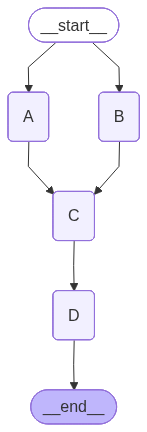


=== Execution with Super-steps ===


  Execution Summary:
  Total time: 0.51s
  Message order: ['B', 'A', 'B', 'A', 'B', 'A', 'C', 'B', 'A', 'B', 'A', 'B', 'A', 'C', 'D', 'B', 'A', 'B', 'A', 'B', 'A', 'C', 'B', 'A', 'B', 'A', 'B', 'A', 'C', 'D']

  Step-by-step log:
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 2: Node C executed (after A and B)
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 2: Node C executed (after A and B)
  Step 3: Node D executed (after C)
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1: Node A executed
  Step 1: Node B executed (parallel with A)
  Step 1

In [33]:
from langgraph.graph import StateGraph, END
from typing import TypedDict
import time
from IPython.display import display, Image
import operator

# State 정의
class GraphState(TypedDict):
    # messages: list[str]
    messages: Annotated[list[str], operator.add] # Append Only
    step_log: Annotated[list[str], operator.add] # Append Only

# 노드 함수들
def node_a(state: GraphState) -> GraphState:
    """독립적으로 실행 가능한 노드 A"""
    time.sleep(0.5)  # 시뮬레이션
    state["messages"].append("A")
    state["step_log"].append(f"Step 1: Node A executed")
    return state

def node_b(state: GraphState) -> GraphState:
    """독립적으로 실행 가능한 노드 B"""
    time.sleep(0.5)
    state["messages"].append("B")
    state["step_log"].append(f"Step 1: Node B executed (parallel with A)")
    return state

def node_c(state: GraphState) -> GraphState:
    """A와 B 이후 실행되는 노드 C"""
    state["messages"].append("C")
    state["step_log"].append(f"Step 2: Node C executed (after A and B)")
    return state

def node_d(state: GraphState) -> GraphState:
    """C 이후 실행되는 노드 D"""
    state["messages"].append("D")
    state["step_log"].append(f"Step 3: Node D executed (after C)")
    return state

# Pregel 그래프 구성
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("A", node_a)
workflow.add_node("B", node_b)
workflow.add_node("C", node_c)
workflow.add_node("D", node_d)

# 엣지 정의 (실행 순서 제어)
workflow.set_entry_point("A")
workflow.set_entry_point("B")  # A와 B는 동시 시작 (Super-step 1)

workflow.add_edge("A", "C")  # C는 A 이후
workflow.add_edge("B", "C")  # C는 B 이후 (Super-step 2)

workflow.add_edge("C", "D")  # D는 C 이후 (Super-step 3)
workflow.add_edge("D", END)

# 컴파일
app = workflow.compile()

# 그래프 시각화
print("=== Pregel Graph Structure ===")
display(Image(app.get_graph().draw_mermaid_png()))

# 실행 및 Super-step 관찰
print("\n=== Execution with Super-steps ===")
print()
start = time.time()

result = app.invoke({
    "messages": [],
    "step_log": []
})

elapsed = time.time() - start

print(f"\n  Execution Summary:")
print(f"  Total time: {elapsed:.2f}s")
print(f"  Message order: {result['messages']}")
print(f"\n  Step-by-step log:")
for log in result['step_log']:
    print(f"  {log}")

print(f"\n  Note: A and B executed in parallel (Super-step 1)")
print(f"   Expected time if sequential: ~2s")
print(f"   Actual time with parallelism: ~{elapsed:.1f}s")

## LangGraph 비동기 실행

### 기본 에이전트 생성 및 비동기 실행

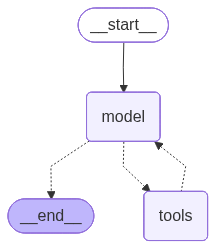

In [35]:
"""LangGraph 에이전트 생성 및 비동기 실행 예제.

간단한 도구를 가진 에이전트를 생성하고,
동기와 비동기 실행을 비교합니다.
"""

# 도구 정의 (비동기로 변경)
@tool
async def calculate_square(number: int) -> int:
    """주어진 숫자의 제곱을 계산합니다.

    Args:
        number: 제곱할 숫자

    Returns:
        number의 제곱
    """
    # 계산 시간 시뮬레이션 (비동기 대기)
    await asyncio.sleep(0.5)
    return number ** 2


@tool
async def calculate_factorial(number: int) -> int:
    """주어진 숫자의 팩토리얼을 계산합니다.

    Args:
        number: 팩토리얼을 계산할 숫자 (0 이상의 정수)

    Returns:
        number의 팩토리얼
    """
    # 계산 시간 시뮬레이션 (비동기 대기)
    await asyncio.sleep(0.5)

    if number < 0:
        raise ValueError("음수의 팩토리얼은 정의되지 않습니다.")
    if number == 0 or number == 1:
        return 1

    result = 1
    for i in range(2, number + 1):
        result *= i
    return result


# 에이전트 생성
tools = [calculate_square, calculate_factorial]
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

agent = create_agent(
    model=model,
    tools=tools,
    name="math_agent"
)
agent


In [ ]:
"""동기 vs 비동기 에이전트 실행 비교.
동일한 작업을 동기와 비동기로 실행하여 성능을 비교합니다.
"""

question = "5의 제곱과 5의 팩토리얼을 각각 계산해주세요."

# NOTE: LangChain's StructuredTool does not support sync invocation.
# 따라서 동기 실행을 할 수 없음
# sync_result = agent.invoke(
#     {"messages": [HumanMessage(content=question)]}
# )

# 비동기 실행
async def async_agent_execution():
    """에이전트를 비동기로 실행하는 함수.

    Returns:
        에이전트 실행 결과
    """
    print("=== 비동기 에이전트 실행 ===")
    async_start = time.time()

    result = await agent.ainvoke(
        {"messages": [HumanMessage(content=question)]}
    )

    async_time = time.time() - async_start
    print(f"비동기 실행 시간: {async_time:.2f}초")
    print(f"응답: {result['messages'][-1].content}")

    return result

async_result = await async_agent_execution()
async_result

=== 비동기 에이전트 실행 ===
비동기 실행 시간: 3.20초
응답: 5의 제곱은 25이고, 5의 팩토리얼은 120입니다.


{'messages': [HumanMessage(content='5의 제곱과 5의 팩토리얼을 각각 계산해주세요.', additional_kwargs={}, response_metadata={}, id='8fc1842b-9788-4518-a267-473fd8486e62'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 145, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CTSkcJOMNfDoYsb20j6DWh7XLD5st', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--a4e7cdd8-919c-48f7-b2ce-42c375141022-0', tool_calls=[{'name': 'calculate_square', 'args': {'number': 5}, 'id': 'call_n7QV4D3UV5C8K2jwlngQSkpC', 'type': 'tool_call'}, {'name': 'calculate_factorial', 'args': {'number': 5}, 'id': 'call_

### 4.2 LangGraph 스트리밍 모드

LangGraph는 다양한 스트리밍 모드를 제공하여 에이전트 실행 과정을 실시간으로 모니터링할 수 있습니다.

#### 주요 스트리밍 모드

| 모드 | 설명 | 사용 사례 |
|------|------|----------|
| `values` | 각 단계 후 전체 상태 스트리밍 | 전체 상태 추적 |
| `updates` | 각 단계의 상태 변경사항만 스트리밍 | 효율적인 업데이트 추적 |
| `messages` | LLM 토큰과 메타데이터 스트리밍 | 실시간 응답 표시 |
| `custom` | 사용자 정의 데이터 스트리밍 | 커스텀 이벤트 추적 |
| `debug` | 최대한 상세한 실행 정보 스트리밍 | 디버깅 |

#### 4.2.1 updates 모드

In [ ]:
"""updates 모드로 에이전트 실행 과정 추적.
각 단계의 상태 변경사항을 실시간으로 출력합니다.
"""

async def stream_with_updates():
    """updates 모드로 에이전트를 스트리밍 실행하는 함수."""
    print("=== updates 모드 스트리밍 ===")

    question = "10의 제곱을 계산하고, 그 결과의 팩토리얼을 계산해주세요."

    async for chunk in agent.astream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="updates"
    ):
        # 각 노드의 업데이트 출력
        for node_name, node_update in chunk.items():
            print(f"\n[{node_name}] 업데이트:")

            # 메시지 업데이트가 있는 경우
            if "messages" in node_update:
                for msg in node_update["messages"]:
                    if hasattr(msg, "content"):
                        print(f"  내용: {msg.content}")
                    if hasattr(msg, "tool_calls") and msg.tool_calls:
                        for tool_call in msg.tool_calls:
                            print(f"  도구 호출: {tool_call['name']}({tool_call['args']})")

await stream_with_updates()

=== updates 모드 스트리밍 ===

[model] 업데이트:
  내용: 
  도구 호출: calculate_square({'number': 10})
  도구 호출: calculate_factorial({'number': 10})

[tools] 업데이트:
  내용: 3628800

[tools] 업데이트:
  내용: 100

[model] 업데이트:
  내용: 10의 제곱은 100이고, 그 결과의 팩토리얼은 3,628,800입니다.


#### 4.2.2 messages 모드


In [ ]:
"""messages 모드로 LLM 토큰 스트리밍.
LLM이 생성하는 토큰을 실시간으로 출력합니다.
"""

async def stream_with_messages():
    """messages 모드로 에이전트를 스트리밍 실행하는 함수."""
    print("=== messages 모드 스트리밍 ===")
    print("LLM 응답: ", end="", flush=True)

    question = "3의 제곱은 얼마인가요?"

    async for chunk in agent.astream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="messages"
    ):
        # 메시지 타입과 내용에 따라 처리
        msg_type, msg_content = chunk
        print(chunk)

    print("\n")  # 줄바꿈

await stream_with_messages()

=== messages 모드 스트리밍 ===
LLM 응답: (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--66d7a36a-7173-4044-8601-9059eed74695', tool_calls=[{'name': 'calculate_square', 'args': {}, 'id': 'call_AqcSwxyzZmBwP72nfOSZ3CvR', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'calculate_square', 'args': '', 'id': 'call_AqcSwxyzZmBwP72nfOSZ3CvR', 'index': 0, 'type': 'tool_call_chunk'}]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:610ef1e4-db5e-6f77-767d-0613993107e3', 'checkpoint_ns': 'model:610ef1e4-db5e-6f77-767d-0613993107e3', 'ls_provider': 'openai', 'ls_model_name': 'gpt-4o-mini', 'ls_model_type': 'chat', 'ls_temperature': 0.0})
(AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--66d7a36a-7173-4044-8601-9059eed74695', tool_calls=[{'name': '', 'args': 

#### 4.2.3 다중 스트리밍 모드


In [ ]:
"""여러 스트리밍 모드를 동시에 사용.

updates와 messages 모드를 함께 사용하여
상태 업데이트와 토큰을 모두 추적합니다.
"""

async def stream_multiple_modes():
    """여러 스트리밍 모드를 동시에 사용하는 함수."""
    print("=== 다중 모드 스트리밍 ===")

    question = "7의 팩토리얼을 계산해주세요."

    async for mode, chunk in agent.astream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode=["updates", "messages"]
    ):
        if mode == "updates":
            print(f"\n[상태 업데이트] {list(chunk.keys())}")
        elif mode == "messages":
            msg_type, msg_content = chunk
            print(f"[토큰 스트리밍] {chunk}")

    print("\n")  # 줄바꿈


await stream_multiple_modes()

=== 다중 모드 스트리밍 ===
[토큰 스트리밍] (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--289979a5-1edc-4f4e-8478-9f62cb347ba6', tool_calls=[{'name': 'calculate_factorial', 'args': {}, 'id': 'call_ppwGmh0iPIu2r5gq3gtJDz1K', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'calculate_factorial', 'args': '', 'id': 'call_ppwGmh0iPIu2r5gq3gtJDz1K', 'index': 0, 'type': 'tool_call_chunk'}]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:87bc3ec6-cee4-a76c-95e0-1ab3d2c042fd', 'checkpoint_ns': 'model:87bc3ec6-cee4-a76c-95e0-1ab3d2c042fd', 'ls_provider': 'openai', 'ls_model_name': 'gpt-4o-mini', 'ls_model_type': 'chat', 'ls_temperature': 0.0})
[토큰 스트리밍] (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--289979a5-1edc-4f4e-8478-9f62cb347ba6', tool_calls=[{'name': 

---
---

## LangChain-LangGraph Agent 의 병렬 처리 전략

### 병렬 도구 호출

일부 LLM(OpenAI, Anthropic 등)은 여러 도구를 동시에 호출할 수 있는 병렬 도구 호출(parallel tool calls)을 지원합니다.

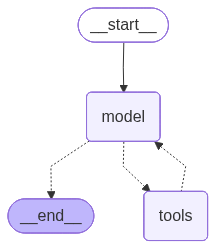

In [ ]:
"""병렬 도구 호출 기능을 활용한 에이전트.

여러 도구를 동시에 호출하여 실행 시간을 단축합니다.
"""

# 시뮬레이션용 도구 정의 (각 도구가 1초씩 소요)
@tool
async def fetch_weather(city: str) -> str:
    """특정 도시의 날씨 정보를 가져옵니다.

    Args:
        city: 도시 이름

    Returns:
        날씨 정보 문자열
    """
    # API 호출 시뮬레이션
    await asyncio.sleep(1.0)
    return f"{city}의 현재 날씨는 맑음입니다. 기온은 20도입니다."


@tool
async def fetch_population(city: str) -> str:
    """특정 도시의 인구 정보를 가져옵니다.

    Args:
        city: 도시 이름

    Returns:
        인구 정보 문자열
    """
    # API 호출 시뮬레이션
    await asyncio.sleep(1.0)
    populations = {
        "서울": "약 960만 명",
        "부산": "약 340만 명",
        "인천": "약 295만 명",
    }
    return f"{city}의 인구는 {populations.get(city, '정보 없음')}입니다."


@tool
async def fetch_time(city: str) -> str:
    """특정 도시의 현재 시간을 가져옵니다.

    Args:
        city: 도시 이름

    Returns:
        시간 정보 문자열
    """
    # API 호출 시뮬레이션
    await asyncio.sleep(1.0)
    return f"{city}의 현재 시간은 오후 3시 30분입니다."


# 병렬 도구 호출을 지원하는 에이전트 생성
parallel_tools = [fetch_weather, fetch_population, fetch_time]
parallel_model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

from langchain.agents import create_agent

# parallel_tool_calls 파라미터는 OpenAI에서 자동으로 처리되고, default=True
parallel_agent = create_agent(
    model=parallel_model,
    tools=parallel_tools,
    name="information_agent",
    debug=True,
)
parallel_agent

In [ ]:
"""병렬 도구 호출의 성능 이점 확인."""

async def test_parallel_tools():
    """병렬 도구 호출을 테스트하는 함수."""
    print("=== 병렬 도구 호출 테스트 ===")

    # 3개의 정보를 모두 요청
    question = "서울의 날씨, 인구, 그리고 현재 시간을 알려주세요."

    start_time = time.time()

    result = await parallel_agent.ainvoke(
        {"messages": [HumanMessage(content=question)]}
    )

    execution_time = time.time() - start_time

    print(f"\n실행 시간: {execution_time:.2f}초")


await test_parallel_tools()

=== 병렬 도구 호출 테스트 ===
[values] {'messages': [HumanMessage(content='서울의 날씨, 인구, 그리고 현재 시간을 알려주세요.', additional_kwargs={}, response_metadata={}, id='e44beecc-8330-48b6-b81e-d43e054a0f3a')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 152, 'total_tokens': 210, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-CTT086mRSa1llcPeORirXixlLEwrX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e40b91da-a956-4db2-b77f-7999e269d167-0', tool_calls=[{'name': 'fetch_weather', 'args': {'city': '서울'}, 'id': 'call_CE6zFjcVOok0NCNk7c8S5jld', 'type': 'tool_call'}, {'

### 여러 에이전트 병렬 실행

독립적인 여러 에이전트를 동시에 실행하여 전체 처리 시간을 단축할 수 있습니다.

In [ ]:
"""여러 전문 에이전트를 병렬로 실행.

각 에이전트가 독립적인 작업을 수행할 때
병렬 실행으로 전체 시간을 단축합니다.
"""

# 수학 에이전트
math_tools = [calculate_square, calculate_factorial]
math_agent = create_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0),
    tools=math_tools,
    name="math_agent"
)

# 정보 에이전트
info_tools = [fetch_weather, fetch_population, fetch_time]
info_agent = create_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0),
    tools=info_tools,
    name="info_agent"
)


async def run_multiple_agents_sequentially():
    """여러 에이전트를 순차적으로 실행하는 함수.

    Returns:
        각 에이전트의 실행 결과 리스트
    """
    print("=== 순차 실행 ===")
    start_time = time.time()

    # 에이전트를 하나씩 실행
    math_result = await math_agent.ainvoke(
        {"messages": [HumanMessage(content="8의 제곱을 계산해주세요.")]}
    )

    info_result = await info_agent.ainvoke(
        {"messages": [HumanMessage(content="부산의 인구를 알려주세요.")]}
    )

    sequential_time = time.time() - start_time
    print(f"순차 실행 시간: {sequential_time:.2f}초\n")

    return [math_result, info_result], sequential_time


async def run_multiple_agents_parallel():
    """여러 에이전트를 병렬로 실행하는 함수.

    Returns:
        각 에이전트의 실행 결과 리스트
    """
    print("=== 병렬 실행 ===")
    start_time = time.time()

    # asyncio.gather를 사용하여 동시에 실행
    results = await asyncio.gather(
        math_agent.ainvoke(
            {"messages": [HumanMessage(content="8의 제곱을 계산해주세요.")]}
        ),
        info_agent.ainvoke(
            {"messages": [HumanMessage(content="부산의 인구를 알려주세요.")]}
        ),
    )

    parallel_time = time.time() - start_time
    print(f"병렬 실행 시간: {parallel_time:.2f}초\n")

    return results, parallel_time

# 실행 및 비교
seq_results, seq_time = await run_multiple_agents_sequentially()
par_results, par_time = await run_multiple_agents_parallel()

print(f"성능 향상: {seq_time / par_time:.2f}배")

print("\n=== 결과 ===")
print(f"수학 에이전트: {par_results[0]['messages'][-1].content}")
print(f"정보 에이전트: {par_results[1]['messages'][-1].content}")

=== 순차 실행 ===
순차 실행 시간: 4.83초

=== 병렬 실행 ===
병렬 실행 시간: 2.59초

성능 향상: 1.86배

=== 결과 ===
수학 에이전트: 8의 제곱은 64입니다.
정보 에이전트: 부산의 인구는 약 340만 명입니다.


### 5.3 배치 처리

동일한 에이전트로 여러 입력을 처리할 때 배치 처리를 사용하면 효율적입니다.

In [ ]:
"""배치 처리를 통한 효율적인 다중 입력 처리.

LangChain의 abatch()를 사용하여 여러 입력을 효율적으로 처리합니다.
"""

async def batch_processing_comparison():
    """배치 처리: asyncio.gather vs abatch 비교."""

    # 여러 입력 준비
    inputs = [
        {"messages": [HumanMessage(content="2의 제곱을 계산해주세요.")]},
        {"messages": [HumanMessage(content="3의 제곱을 계산해주세요.")]},
        {"messages": [HumanMessage(content="4의 제곱을 계산해주세요.")]},
        {"messages": [HumanMessage(content="5의 제곱을 계산해주세요.")]},
    ]

    # 방법 1: asyncio.gather 사용 (일반적인 병렬 실행)
    print("=== 방법 1: asyncio.gather 사용 ===")
    start_time = time.time()

    gather_results = await asyncio.gather(
        *[math_agent.ainvoke(inp) for inp in inputs]
    )

    gather_time = time.time() - start_time
    print(f"실행 시간: {gather_time:.2f}초")
    print("결과:")
    for i, result in enumerate(gather_results, 1):
        print(f"  {i}. {result['messages'][-1].content}")

    print("\n" + "="*80 + "\n")

    # 방법 2: abatch() 사용 (내부적으로는 ainvoke 병렬 실행 - 사실상 1번과 같은 방법임)
    print("=== 방법 2: abatch() 사용 ===")
    start_time = time.time()

    #   LangChain의 abatch() 메서드 사용
    abatch_results = await math_agent.abatch(inputs)

    abatch_time = time.time() - start_time
    print(f"실행 시간: {abatch_time:.2f}초")
    print("결과:")
    for i, result in enumerate(abatch_results, 1):
        print(f"  {i}. {result['messages'][-1].content}")

    print("\n" + "="*80 + "\n")

await batch_processing_comparison()

=== 방법 1: asyncio.gather 사용 ===
실행 시간: 2.15초
결과:
  1. 2의 제곱은 4입니다.
  2. 3의 제곱은 9입니다.
  3. 4의 제곱은 16입니다.
  4. 5의 제곱은 25입니다.


=== 방법 2: abatch() 사용 ===
실행 시간: 2.53초
결과:
  1. 2의 제곱은 4입니다.
  2. 3의 제곱은 9입니다.
  3. 4의 제곱은 16입니다.
  4. 5의 제곱은 25입니다.




### LangGraph 병렬 처리 패턴: Send API와 Queue 기반 처리

지금까지 다룬 패턴들은 주로 **외부 도구**(`asyncio.gather()`, `abatch()`)를 사용한 병렬 처리였습니다.

이번 섹션에서는 LangGraph의 **네이티브 병렬 실행 메커니즘**과 일반적으로 Background Worker 시스템의 기초가 되는 **Queue 기반 패턴**을 다룹니다.

**학습 목표:**
-   LangGraph Send API로 동적 병렬 실행 구현
-   Queue + SubGraph 패턴으로 독립 작업 병렬 처리
-   언제 어떤 패턴을 사용해야 하는지 이해

#### LangGraph Send API - 동적 병렬 실행

**Send API**는 LangGraph의 강력한 기능으로, **런타임에 동적으로 여러 노드를 병렬 실행**할 수 있게 해줍니다.

**핵심 개념:**
- 하나의 노드에서 여러 `Send()` 객체를 반환하면, 각각이 병렬로 실행됩니다
- **같은 thread_id** 내에서 실행 (하나의 워크플로우)
- Map-Reduce 패턴 구현에 최적화

**언제 사용하나요?**
- 하나의 워크플로우 내에서 작업을 동적으로 분산해야 할 때
- 여러 소스에서 데이터를 병렬로 가져와 하나로 합쳐야 할 때
- Map-Reduce 패턴을 구현할 때

**예제: Multi-source RAG 검색**

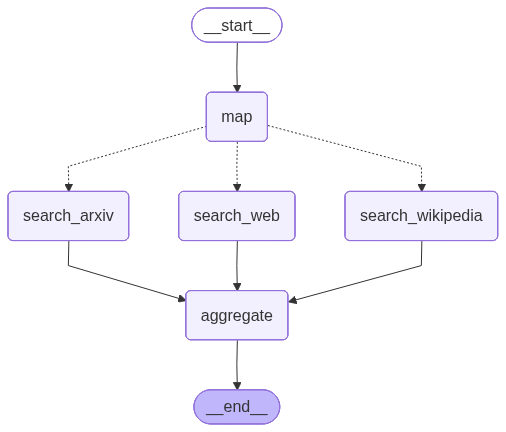

In [ ]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator
import asyncio

# State 정의
class MultiSearchState(TypedDict):
    query: str
    results: Annotated[list[dict], operator.add]  # 결과를 누적

# Map 컨디션 함수
def map_search_condition(state: MultiSearchState) -> list[Send]:
    """하나의 쿼리를 여러 소스에 병렬로 전달"""
    query = state["query"]

    # 각 소스마다 Send 객체 생성 → 병렬 실행!
    return [
        Send("search_arxiv", {"query": query, "results": []}),
        Send("search_wikipedia", {"query": query, "results": []}),
        Send("search_web", {"query": query, "results": []}),
    ]

# Worker 노드들 (각 소스별 검색)
async def search_arxiv(state: MultiSearchState) -> dict:
    """ArXiv에서 검색 (시뮬레이션)"""
    await asyncio.sleep(0.5)  # API 호출 시뮬레이션
    return {
        "results": [{
            "source": "arxiv",
            "title": f"Paper about {state['query']}",
            "summary": "Academic research findings..."
        }]
    }

async def search_wikipedia(state: MultiSearchState) -> dict:
    """Wikipedia에서 검색 (시뮬레이션)"""
    await asyncio.sleep(0.3)
    return {
        "results": [{
            "source": "wikipedia",
            "title": f"Article: {state['query']}",
            "summary": "General knowledge overview..."
        }]
    }

async def search_web(state: MultiSearchState) -> dict:
    """Web 검색 (시뮬레이션)"""
    await asyncio.sleep(0.4)
    return {
        "results": [{
            "source": "web",
            "title": f"News: {state['query']}",
            "summary": "Latest news and updates..."
        }]
    }

# Reduce 노드: 결과 수집 및 처리
def aggregate_results(state: MultiSearchState) -> dict:
    """모든 검색 결과를 하나로 합침"""
    print(f"\n  수집된 결과: {len(state['results'])}개")
    for result in state['results']:
        print(f"  - {result['source']}: {result['title']}")

    return {"results": state["results"]}

# 그래프 구성
builder: StateGraph = StateGraph(MultiSearchState)

# 노드 추가
builder.add_node("map", lambda x:x)
builder.add_node("search_arxiv", search_arxiv)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("search_web", search_web)
builder.add_node("aggregate", aggregate_results)

# 엣지 설정
builder.add_edge(START, "map")
builder.add_conditional_edges("map", map_search_condition, ['search_arxiv', 'search_wikipedia', 'search_web'])
builder.add_edge("search_arxiv", "aggregate")
builder.add_edge("search_wikipedia", "aggregate")
builder.add_edge("search_web", "aggregate")
builder.add_edge("aggregate", END)

# 컴파일
send_api_graph = builder.compile()
send_api_graph

In [ ]:
# Send API 실행
import time

async def run_send_api_example():
    print("  Multi-source RAG 검색 시작...\n")

    start = time.time()

    result = await send_api_graph.ainvoke({
        "query": "LangGraph async patterns",
        "results": []
    })

    elapsed = time.time() - start

    print(f"\n  총 실행 시간: {elapsed:.2f}초")
    print(f"\n  3개의 검색이 병렬로 실행되어 ~0.5초만 소요!")
    print(f"   (Sequential: 0.5 + 0.3 + 0.4 = 1.2초)")

# 실행
await run_send_api_example()

  Multi-source RAG 검색 시작...


  수집된 결과: 3개
  - arxiv: Paper about LangGraph async patterns
  - wikipedia: Article: LangGraph async patterns
  - web: News: LangGraph async patterns

⏱️  총 실행 시간: 0.51초

  3개의 검색이 병렬로 실행되어 ~0.5초만 소요!
   (Sequential: 0.5 + 0.3 + 0.4 = 1.2초)


**  Send API의 핵심 특징:**

1. **같은 thread_id 내 실행**: 모든 worker가 같은 워크플로우의 일부
2. **동적 병렬 실행**: `map_searches`가 런타임에 Send 객체들을 반환
3. **State 자동 merge**: `Annotated[list, operator.add]`로 결과 자동 누적
4. **Map-Reduce 패턴**: Map → Parallel Workers → Reduce

**한계:**
- 모든 작업이 같은 State를 공유 → State 충돌 가능성
- 완전히 독립적인 작업에는 부적합
- Resource control이 어려움 (몇 개까지 동시 실행할지 제한 불가)

→ 이런 한계를 극복하기 위해 **Queue + SubGraph 패턴** 사용!

#### 5.4.2 Queue + SubGraph - 독립 워크플로우 병렬 실행

**Queue + SubGraph 패턴**은 **완전히 독립적인 작업들**을 병렬 처리할 때 사용합니다.

**핵심 아이디어:**
- Queue에 작업들을 저장
- 여러 Worker가 Queue에서 작업을 꺼내서 처리
- **각 작업마다 독립적인 SubGraph를 새로운 thread_id로 실행**

**왜 SubGraph를 독립 thread에서 실행하나요?**

| 측면 | Send API (같은 thread) | Queue + SubGraph (독립 thread) |
|------|----------------------|-------------------------------|
| **State 관리** | 공유 State (충돌 가능) | **완전 격리** |
| **Conversation** | 하나의 history | **각각 독립 history** |
| **에러 격리** | 영향 있음 | **완전 격리** |
| **Resource 제어** | 어려움 | **Worker 개수로 제어** |
| **사용 예** | Multi-source RAG | **대량 문서 분석** |

**언제 사용하나요?**
- 각 작업이 완전히 독립적일 때 (문서 A의 분석은 문서 B와 무관)
- 각 작업이 복잡한 multi-step 워크플로우일 때 (SubGraph로 구현)
- Rate limiting이 필요할 때 (API 호출 제한)
- Resource control이 필요할 때 (동시 실행 개수 제한)

**예제: 여러 문서를 독립적으로 분석**

In [ ]:
import asyncio
import uuid
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# SubGraph의 State 정의
class DocumentState(TypedDict):
    document_id: str
    content: str
    analysis: str
    status: str

# SubGraph 생성: 각 문서 분석 워크플로우
def create_document_analyzer_subgraph():
    """각 문서를 분석하는 독립적인 SubGraph"""

    async def extract_info(state: DocumentState) -> dict:
        """1단계: 정보 추출"""
        await asyncio.sleep(0.5)
        print(f"    [{state['document_id']}] Step 1: 정보 추출 중...")
        return {"status": "extracted"}

    async def classify_content(state: DocumentState) -> dict:
        """2단계: 분류"""
        await asyncio.sleep(0.5)
        print(f"   ️  [{state['document_id']}] Step 2: 문서 분류 중...")
        return {"status": "classified"}

    async def generate_summary(state: DocumentState) -> dict:
        """3단계: 요약 생성"""
        await asyncio.sleep(0.5)
        print(f"    [{state['document_id']}] Step 3: 요약 생성 중...")
        analysis = f"Analysis of {state['document_id']}: {state['content'][:30]}..."
        return {"analysis": analysis, "status": "completed"}

    # SubGraph 구성
    builder = StateGraph(DocumentState)
    builder.add_node("extract", extract_info)
    builder.add_node("classify", classify_content)
    builder.add_node("summarize", generate_summary)

    builder.add_edge(START, "extract")
    builder.add_edge("extract", "classify")
    builder.add_edge("classify", "summarize")
    builder.add_edge("summarize", END)

    # Checkpointer로 각 thread의 상태 관리
    return builder.compile(checkpointer=MemorySaver())

# Queue Worker: Queue에서 작업을 꺼내서 SubGraph 실행
async def document_worker(worker_id: int, queue: asyncio.Queue, subgraph):
    """Worker: Queue에서 문서를 꺼내서 독립 SubGraph로 분석"""
    print(f"\n  Worker {worker_id} 시작!")

    while True:
        # Queue에서 작업 가져오기
        task = await queue.get()

        if task is None:  # Poison pill (종료 신호)
            print(f"\n  Worker {worker_id} 종료")
            queue.task_done()
            break

        doc_id, content = task

        #   핵심: 각 문서마다 독립적인 thread_id!
        thread_id = f"doc-{doc_id}-{uuid.uuid4().hex[:8]}"
        config = {"configurable": {"thread_id": thread_id}}

        print(f"\n  Worker {worker_id} → 문서 '{doc_id}' 처리 (thread: {thread_id})")

        # SubGraph 실행 (독립 thread에서!)
        result = await subgraph.ainvoke(
            {
                "document_id": doc_id,
                "content": content,
                "analysis": "",
                "status": "pending"
            },
            config=config
        )

        print(f"    [{doc_id}] 완료: {result['analysis']}")

        queue.task_done()

# 메인 실행 함수
async def run_queue_subgraph_example():
    """Queue + SubGraph 패턴 실행"""
    print("\n" + "="*60)
    print("  Queue + SubGraph 패턴: 독립 문서 분석")
    print("="*60)

    # SubGraph 생성
    analyzer_subgraph = create_document_analyzer_subgraph()

    # Queue 생성
    queue = asyncio.Queue()

    # 작업 추가 (5개 문서)
    documents = [
        ("doc-001", "Introduction to async programming in Python..."),
        ("doc-002", "LangGraph multi-agent systems guide..."),
        ("doc-003", "Best practices for production deployment..."),
        ("doc-004", "Understanding RAG patterns and techniques..."),
        ("doc-005", "Advanced LangChain middleware strategies..."),
    ]

    for doc in documents:
        await queue.put(doc)

    print(f"\n  Queue에 {len(documents)}개 문서 추가 완료")

    # 3개의 Worker 생성 (동시 실행 제어!)
    num_workers = 3
    print(f"  {num_workers}개 Worker로 병렬 처리 시작...\n")

    workers = [
        asyncio.create_task(
            document_worker(i+1, queue, analyzer_subgraph)
        )
        for i in range(num_workers)
    ]

    # 모든 작업 완료 대기
    await queue.join()

    # Worker 종료 신호
    for _ in range(num_workers):
        await queue.put(None)

    # Worker 종료 대기
    await asyncio.gather(*workers)

In [58]:
# Queue + SubGraph 실행
await run_queue_subgraph_example()


  Queue + SubGraph 패턴: 독립 문서 분석

  Queue에 5개 문서 추가 완료
  3개 Worker로 병렬 처리 시작...


  Worker 1 시작!

  Worker 1 → 문서 'doc-001' 처리 (thread: doc-doc-001-5851740e)

  Worker 2 시작!

  Worker 2 → 문서 'doc-002' 처리 (thread: doc-doc-002-d111e9b7)

  Worker 3 시작!

  Worker 3 → 문서 'doc-003' 처리 (thread: doc-doc-003-e553a4d3)
    [doc-001] Step 1: 정보 추출 중...
    [doc-002] Step 1: 정보 추출 중...
    [doc-003] Step 1: 정보 추출 중...
   ️  [doc-001] Step 2: 문서 분류 중...
   ️  [doc-002] Step 2: 문서 분류 중...
   ️  [doc-003] Step 2: 문서 분류 중...
    [doc-001] Step 3: 요약 생성 중...
    [doc-002] Step 3: 요약 생성 중...
    [doc-003] Step 3: 요약 생성 중...
    [doc-001] 완료: Analysis of doc-001: Introduction to async programm...

  Worker 1 → 문서 'doc-004' 처리 (thread: doc-doc-004-e0afc20c)
    [doc-002] 완료: Analysis of doc-002: LangGraph multi-agent systems ...

  Worker 2 → 문서 'doc-005' 처리 (thread: doc-doc-005-c5d6779f)
    [doc-003] 완료: Analysis of doc-003: Best practices for production ...
    [doc-004] Step 1: 정보 추출 중...
    [doc-00

#### Queue 사용 패턴

기본 Queue 패턴에 **우선순위 처리**와 **Rate Limiting**을 추가해 production-ready하게 만들 수 있습니다.

**학습할 패턴:**
1. **Priority Queue**: 중요한 작업을 먼저 처리
2. **Rate-Limited Queue**: API 호출 제한 준수 (Semaphore 활용)

##### Priority Queue - 중요도 기반 처리

**사용 사례:**
- VIP 고객 요청 우선 처리
- 긴급 알림 우선 발송
- 중요 문서 우선 분석

**핵심:** `asyncio.PriorityQueue`로 낮은 숫자 = 높은 우선순위

In [ ]:
import asyncio
from typing import Tuple

async def priority_queue_worker(worker_id: int, queue: asyncio.PriorityQueue, subgraph):
    """Priority Queue Worker: 우선순위가 높은 작업부터 처리"""
    while True:
        # Queue에서 우선순위가 높은 작업 가져오기
        item = await queue.get()

        if item is None:
            queue.task_done()
            break

        priority, (doc_id, content) = item

        # 우선순위 표시
        priority_label = {
            0: "  긴급",
            1: "🟡 높음",
            2: "🟢 보통"
        }.get(priority, "  낮음")

        print(f"Worker {worker_id} → {priority_label} '{doc_id}' 처리 중")

        # SubGraph 실행
        thread_id = f"priority-{doc_id}-{worker_id}"
        await subgraph.ainvoke(
            {
                "document_id": doc_id,
                "content": content,
                "analysis": "",
                "status": "pending"
            },
            config={"configurable": {"thread_id": thread_id}}
        )

        print(f"    Worker {worker_id} → '{doc_id}' 완료\n")
        queue.task_done()

async def run_priority_queue_example():
    """Priority Queue 예제 실행"""
    print("\n" + "="*60)
    print("  Priority Queue: 중요도 기반 처리")
    print("="*60 + "\n")

    analyzer = create_document_analyzer_subgraph()
    queue = asyncio.PriorityQueue()

    # 작업 추가 (priority, task)
    tasks = [
        (2, ("doc-normal-1", "Regular document...")),
        (0, ("doc-urgent", "URGENT: Critical security alert!")),  # 최우선!
        (1, ("doc-high", "High priority customer request...")),
        (2, ("doc-normal-2", "Another regular doc...")),
    ]

    for task in tasks:
        await queue.put(task)

    print("  작업 추가 순서:")
    print("   1. 🟢 doc-normal-1 (우선순위: 2)")
    print("   2.   doc-urgent (우선순위: 0) ← 긴급!")
    print("   3. 🟡 doc-high (우선순위: 1)")
    print("   4. 🟢 doc-normal-2 (우선순위: 2)\n")

    print("실제 처리 순서 (우선순위 높은 것부터):")
    print("-" * 60 + "\n")

    # 2개 Worker 시작
    workers = [
        asyncio.create_task(priority_queue_worker(i+1, queue, analyzer))
        for i in range(2)
    ]

    await queue.join()

    for _ in range(2):
        await queue.put({})

    await asyncio.gather(*workers)

##### Rate-Limited Queue - API 제한 준수

**사용 사례:**
- OpenAI API: 초당 20 요청 제한
- 외부 API: Rate limit 준수 필요
- DB 동시 연결 제한

**핵심:** `asyncio.Semaphore`로 동시 실행 개수 제한

In [ ]:
import asyncio
import time
from typing import Optional

class RateLimitedQueue:
    """Rate Limiting 기능이 있는 Queue"""

    def __init__(self, max_concurrent: int, requests_per_second: Optional[float] = None):
        self.queue = asyncio.Queue()
        self.semaphore = asyncio.Semaphore(max_concurrent)
        self.requests_per_second = requests_per_second
        self.last_request_time = 0

    async def put(self, item):
        await self.queue.put(item)

    async def get(self):
        item = await self.queue.get()

        # Rate limiting: 초당 요청 수 제한
        if self.requests_per_second:
            min_interval = 1.0 / self.requests_per_second
            elapsed = time.time() - self.last_request_time

            if elapsed < min_interval:
                sleep_time = min_interval - elapsed
                await asyncio.sleep(sleep_time)

            self.last_request_time = time.time()

        return item

    def task_done(self):
        self.queue.task_done()

    async def join(self):
        await self.queue.join()

async def rate_limited_worker(worker_id: int, queue: RateLimitedQueue, subgraph):
    """Rate-Limited Worker"""
    while True:
        # Semaphore로 동시 실행 제어
        async with queue.semaphore:
            task = await queue.get()

            if task is None:
                queue.task_done()
                break

            doc_id, content = task

            print(f"Worker {worker_id} → '{doc_id}' 시작 (시각: {time.strftime('%H:%M:%S')})")

            thread_id = f"rate-limited-{doc_id}"
            await subgraph.ainvoke(
                {
                    "document_id": doc_id,
                    "content": content,
                    "analysis": "",
                    "status": "pending"
                },
                config={"configurable": {"thread_id": thread_id}}
            )

            print(f"    Worker {worker_id} → '{doc_id}' 완료\n")
            queue.task_done()

async def run_rate_limited_queue_example():
    """Rate-Limited Queue 예제"""
    print("\n" + "="*60)
    print("  Rate-Limited Queue: API 제한 준수")
    print("="*60 + "\n")

    analyzer = create_document_analyzer_subgraph()

    # Rate Limit: 최대 2개 동시 실행, 초당 1개 요청
    queue = RateLimitedQueue(
        max_concurrent=2,
        requests_per_second=1.0  # 1초에 1개 요청만!
    )

    # 5개 작업 추가
    documents = [
        (f"doc-{i:03d}", f"Document {i} content...")
        for i in range(1, 6)
    ]

    for doc in documents:
        await queue.put(doc)

    print(" ️  설정:")
    print("   - 최대 동시 실행: 2개")
    print("   - Rate Limit: 초당 1개 요청")
    print(f"   - 총 작업: {len(documents)}개\n")

    print("실행 로그 (Rate Limiting 적용):")
    print("-" * 60 + "\n")

    start = time.time()

    # 5개 Worker 생성 (하지만 max_concurrent=2로 제한!)
    workers = [
        asyncio.create_task(rate_limited_worker(i+1, queue, analyzer))
        for i in range(5)
    ]

    await queue.join()

    for _ in range(5):
        await queue.put(None)

    await asyncio.gather(*workers)

    elapsed = time.time() - start

In [64]:
# Priority Queue 실행
await run_priority_queue_example()

# Rate-Limited Queue 실행
await run_rate_limited_queue_example()


  Priority Queue: 중요도 기반 처리

  작업 추가 순서:
   1. 🟢 doc-normal-1 (우선순위: 2)
   2.   doc-urgent (우선순위: 0) ← 긴급!
   3. 🟡 doc-high (우선순위: 1)
   4. 🟢 doc-normal-2 (우선순위: 2)

실제 처리 순서 (우선순위 높은 것부터):
------------------------------------------------------------

Worker 1 →   긴급 'doc-urgent' 처리 중
Worker 2 → 🟡 높음 'doc-high' 처리 중
    [doc-urgent] Step 1: 정보 추출 중...
    [doc-high] Step 1: 정보 추출 중...
   ️  [doc-urgent] Step 2: 문서 분류 중...
   ️  [doc-high] Step 2: 문서 분류 중...
    [doc-urgent] Step 3: 요약 생성 중...
    [doc-high] Step 3: 요약 생성 중...
    Worker 1 → 'doc-urgent' 완료

Worker 1 → 🟢 보통 'doc-normal-1' 처리 중
    Worker 2 → 'doc-high' 완료

Worker 2 → 🟢 보통 'doc-normal-2' 처리 중
    [doc-normal-1] Step 1: 정보 추출 중...
    [doc-normal-2] Step 1: 정보 추출 중...
   ️  [doc-normal-1] Step 2: 문서 분류 중...
   ️  [doc-normal-2] Step 2: 문서 분류 중...
    [doc-normal-1] Step 3: 요약 생성 중...
    [doc-normal-2] Step 3: 요약 생성 중...
    Worker 1 → 'doc-normal-1' 완료

    Worker 2 → 'doc-normal-2' 완료



TypeError: '<' not supported between instances of 'dict' and 'dict'

##### 핵심 정리

**1. Send API (LangGraph 네이티브)**
-   장점: 같은 워크플로우 내 동적 병렬 실행, State 자동 merge
-  ️ 한계: State 공유 (충돌 가능), Resource 제어 어려움
-   사용: Map-Reduce, Multi-source aggregation

**2. Queue + SubGraph (Production 패턴)**
-   장점: **완전히 독립적인 thread**, State 격리, Worker 개수로 제어
-  ️ 한계: 구현 복잡도 높음
-   사용: **대량 문서 처리, 각 작업이 복잡한 워크플로우**

**3. Priority Queue**
-   장점: 중요한 작업 우선 처리
-   사용: VIP 고객 우선, 긴급 알림 우선

**4. Rate-Limited Queue**
-   장점: API 제한 준수, Semaphore로 동시 실행 제어
-   사용: 외부 API 호출, DB 연결 제한

**핵심 원칙:**
> "같은 워크플로우 내 병렬 → Send API"
>
> "독립 작업 + 복잡한 워크플로우 → Queue + SubGraph"
>
> "우선순위/Rate Limit → 고급 Queue 패턴"

## Best Practices 및 주의사항

### 비동기 프로그래밍 Best Practices

#### 1. 이벤트 루프 블로킹 방지

비동기 함수 내에서 동기 블로킹 작업(예: `time.sleep()`, 블로킹 I/O)을 사용하면 안 됩니다.

```python
# 잘못된 예
async def bad_async_function():
    time.sleep(1)  # 이벤트 루프를 블로킹!

# 올바른 예
async def good_async_function():
    await asyncio.sleep(1)  # 이벤트 루프를 블로킹하지 않음
```

#### 2. 동기 함수를 비동기로 실행

필요한 경우 `asyncio.to_thread()`를 사용하여 동기 함수를 별도 스레드에서 실행할 수 있습니다.

```python
import asyncio

def sync_blocking_function():
    time.sleep(1)
    return "결과"

async def async_wrapper():
    # 동기 함수를 별도 스레드에서 실행
    # **실전에서는 실제로 굉장히 강력한 성능을 낼 수 있습니다!**
    result = await asyncio.to_thread(sync_blocking_function)
    return result
```

#### 3. 에러 처리

`asyncio.gather()`는 기본적으로 첫 번째 예외 발생 시 중단됩니다. `return_exceptions=True`를 사용하여 모든 작업을 완료할 수 있습니다.

```python
# 예외가 발생해도 모든 작업 완료
results = await asyncio.gather(
    task1(),
    task2(),
    task3(),
    return_exceptions=True
)

# 결과 처리
for result in results:
    if isinstance(result, Exception):
        print(f"에러 발생: {result}")
    else:
        print(f"성공: {result}")
```

### LangGraph 비동기 사용 시 주의사항

#### 1. 도구의 비동기 지원

도구가 비동기를 지원하는지 확인하세요. 비동기 도구는 `async def`로 정의합니다.

```python
from langchain_core.tools import tool

@tool
async def async_tool(query: str) -> str:
    """비동기 도구 예제."""
    # 비동기 작업 수행
    result = await some_async_operation(query)
    return result
```

#### 2. Checkpointer의 비동기 지원

체크포인터를 사용할 때 비동기 메서드(`aget`, `aput` 등)를 지원하는지 확인하세요.

```python
from langgraph.checkpoint.memory import MemorySaver

# MemorySaver는 비동기를 지원합니다
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

# 비동기 실행
result = await app.ainvoke({...}, config={"thread_id": "1"})
```

#### 3. RunnableConfig 전달

Python 3.11 미만에서는 스트리밍 시 `RunnableConfig`를 명시적으로 전달해야 할 수 있습니다.

```python
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    configurable={"thread_id": "1"},
    callbacks=[...],
)

async for chunk in agent.astream(inputs, config):
    print(chunk)
```

### 비동기 기반 성능 최적화 팁

#### 1. 적절한 병렬도 `선택적으로 고려하세요`

너무 많은 병렬 요청은 API 제한에 걸리거나 리소스를 고갈시킬 수 있습니다.

```python
# 세마포어를 사용한 동시 실행 제한
semaphore = asyncio.Semaphore(5)  # 최대 5개 동시 실행

async def limited_task(task):
    async with semaphore:
        return await task

tasks = [limited_task(agent.ainvoke(input)) for input in inputs]
results = await asyncio.gather(*tasks)
```

#### 2. 타임아웃 설정

무한 대기를 방지하기 위해 타임아웃을 설정하세요.

```python
try:
    result = await asyncio.wait_for(
        agent.ainvoke(inputs),
        timeout=30.0  # 30초 타임아웃
    )
except asyncio.TimeoutError:
    print("작업이 타임아웃되었습니다.")
```

#### 3. 캐싱 활용

동일한 입력에 대해 반복 호출하는 경우 캐싱을 활용하세요.

```python
from functools import lru_cache

@lru_cache(maxsize=100)
def get_cached_result(query: str) -> str:
    # 캐시된 결과 반환
    return result
```

### 디버깅 팁

#### 1. 디버그 모드 스트리밍

```python
# 상세한 디버그 정보 출력
async for chunk in agent.astream(inputs, stream_mode="debug"):
    print(chunk)
```

#### 2. 로깅 활성화

```python
import logging

# LangChain 로깅 활성화
logging.basicConfig(level=logging.DEBUG)
logging.getLogger("langchain").setLevel(logging.DEBUG)
```

#### 3. 실행 시간 측정

```python
import time

async def timed_execution(coro):
    start = time.time()
    result = await coro
    duration = time.time() - start
    print(f"실행 시간: {duration:.2f}초")
    return result

result = await timed_execution(agent.ainvoke(inputs))
```

### API 에러 재시도 전략

실전 환경에서는 네트워크 오류, API 타임아웃, 레이트 리밋(429 에러) 등이 빈번하게 발생합니다.  
**재시도 전략 없이는 프로덕션 시스템이 불안정합니다.**

#### tenacity 라이브러리

Python의 업계 표준 재시도 라이브러리입니다.

**주요 기능:**
- 지수 백오프 (Exponential Backoff)
- 특정 예외만 재시도
- 최대 재시도 횟수 제한
- 재시도 간 대기 시간 커스터마이징

**설치:**
```bash
pip install tenacity
```

In [ ]:
"""비동기 재시도 전략 구현.

tenacity를 사용하여 LLM 호출의 안정성을 높입니다."""

try:
    from tenacity import (
        retry,
        stop_after_attempt,
        wait_exponential,
        retry_if_exception_type,
        before_sleep_log,
    )
    import logging

    # 로깅 설정
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger(__name__)


    @retry(
        stop=stop_after_attempt(3),  # 최대 3회 재시도
        wait=wait_exponential(multiplier=1, min=2, max=10),  # 2초, 4초, 8초...
        retry=retry_if_exception_type((TimeoutError, ConnectionError)),
        before_sleep=before_sleep_log(logger, logging.WARNING),  # 재시도 전 로그
    )
    async def resilient_llm_call(prompt: str) -> str:
        """에러 시 자동 재시도하는 LLM 호출.

        Args:
            prompt: LLM 프롬프트

        Returns:
            LLM 응답

        Raises:
            Exception: 3회 재시도 후에도 실패 시
        """
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        response = await llm.ainvoke([HumanMessage(content=prompt)])
        return response.content


    # 실전 예제: 여러 LLM 호출을 안전하게 병렬 실행
    async def safe_parallel_llm_calls():
        """재시도 전략을 적용한 병렬 LLM 호출."""
        print("=== 재시도 전략이 적용된 병렬 LLM 호출 ===\n")

        prompts = [
            "Python의 장점을 한 문장으로 설명하세요.",
            "비동기 프로그래밍이란?",
            "LangChain의 주요 기능은?",
        ]

        try:
            # 모든 호출에 재시도 적용
            results = await asyncio.gather(
                *[resilient_llm_call(p) for p in prompts],
                return_exceptions=True  # 일부 실패해도 계속 진행
            )

            # 결과 처리
            for i, (prompt, result) in enumerate(zip(prompts, results), 1):
                if isinstance(result, Exception):
                    print(f"{i}.   실패: {prompt}")
                    print(f"   에러: {result}\n")
                else:
                    print(f"{i}.   성공: {prompt}")
                    print(f"   응답: {result}\n")

        except Exception as e:
            print(f"치명적 에러: {e}")


    await safe_parallel_llm_calls()

except ImportError:
    print("tenacity 라이브러리가 설치되어 있지 않습니다. 'pip install tenacity'로 설치해주세요.")

=== 재시도 전략이 적용된 병렬 LLM 호출 ===



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


1.   성공: Python의 장점을 한 문장으로 설명하세요.
   응답: Python은 간결하고 읽기 쉬운 문법 덕분에 빠른 개발과 유지보수를 가능하게 하여, 다양한 분야에서 널리 사용되는 프로그래밍 언어입니다.

2.   성공: 비동기 프로그래밍이란?
   응답: 비동기 프로그래밍(Asynchronous Programming)은 프로그램의 실행 흐름을 효율적으로 관리하기 위한 프로그래밍 패러다임입니다. 전통적인 동기 프로그래밍에서는 작업이 순차적으로 실행되며, 하나의 작업이 완료될 때까지 다음 작업이 시작되지 않습니다. 반면, 비동기 프로그래밍에서는 작업이 완료될 때까지 기다리지 않고, 다른 작업을 동시에 진행할 수 있습니다.

비동기 프로그래밍의 주요 특징은 다음과 같습니다:

1. **병렬 처리**: 여러 작업을 동시에 수행할 수 있어, CPU 자원을 효율적으로 사용할 수 있습니다.

2. **I/O 작업의 효율성**: 네트워크 요청, 파일 읽기/쓰기 등 시간이 걸리는 작업을 비동기로 처리하면, 해당 작업이 완료될 때까지 프로그램이 멈추지 않고 다른 작업을 수행할 수 있습니다.

3. **콜백, 프로미스, async/await**: 비동기 프로그래밍에서는 콜백 함수, 프로미스(Promise), async/await와 같은 패턴을 사용하여 비동기 작업의 결과를 처리합니다. 이러한 패턴은 코드의 가독성을 높이고, 비동기 작업의 흐름을 더 쉽게 관리할 수 있게 해줍니다.

4. **이벤트 루프**: JavaScript와 같은 언어에서는 이벤트 루프(Event Loop)를 통해 비동기 작업을 관리합니다. 이벤트 루프는 대기 중인 작업을 처리하고, 완료된 작업의 결과를 적절한 콜백 함수에 전달합니다.

비동기 프로그래밍은 특히 웹 개발, 네트워크 프로그래밍, 데이터베이스 작업 등에서 매우 유용하게 사용됩니다. 이를 통해 사용자 경험을 향상시키고, 시스템의 성능을 극대화할 수 있습니다.

3.   성공: LangChain의 주요 기능은?
   응답: LangCha

### 7.5 멀티 에이전트 시스템: 공유 자원 안전하게 접근하기

여러 에이전트가 동시에 공유 자원(파일, 캐시, 데이터베이스 등)에 접근할 때,
**Race Condition**을 방지해야 합니다.

#### 문제 상황

```python
# 잘못된 예: Race Condition 발생 가능
shared_cache = {}

async def update_cache(key, value):
    # 여러 에이전트가 동시에 접근하면 데이터 손실 가능!
    shared_cache[key] = value
```

#### 해결책: asyncio.Lock

비동기 락(Lock)을 사용하여 한 번에 하나의 코루틴만 접근하도록 보장합니다.

In [ ]:
"""비동기 락을 사용한 안전한 공유 자원 접근.

멀티 에이전트 시스템에서 Race Condition을 방지합니다."""

from typing import Dict

# 공유 캐시 (여러 에이전트가 동시에 접근)
shared_cache: Dict[str, str] = {}
cache_lock = asyncio.Lock()  # 비동기 락 생성 - 하지만 "느려질 수" 있다는 것을 꼭 기억하셔야 합니다.


async def safe_cache_update(agent_name: str, key: str, value: str):
    """락을 사용한 안전한 캐시 업데이트.

    Args:
        agent_name: 에이전트 이름
        key: 캐시 키
        value: 캐시 값
    """
    print(f"[{agent_name}] 캐시 업데이트 시도...")

    async with cache_lock:  # 락 획득
        print(f"[{agent_name}] 락 획득! 캐시 업데이트 중...")

        # 복잡한 작업 시뮬레이션
        await asyncio.sleep(0.5)
        shared_cache[key] = value

        print(f"[{agent_name}] 캐시 업데이트 완료: {key}={value}")
    # with 블록을 벗어나면 자동으로 락 해제


async def unsafe_cache_update(agent_name: str, key: str, value: str):
    """락 없이 캐시 업데이트 (문제 발생 가능).

    Args:
        agent_name: 에이전트 이름
        key: 캐시 키
        value: 캐시 값
    """
    print(f"[{agent_name}] 캐시 업데이트 시도... (락 없음)")
    await asyncio.sleep(0.5)
    shared_cache[key] = value
    print(f"[{agent_name}] 완료: {key}={value}")


async def demonstrate_race_condition():
    """Race Condition 시연 및 해결책 비교."""

    # 1. 락 없는 경우 (Race Condition 발생 가능)
    print("=== 1. 락 없이 실행 (위험!) ===\n")
    shared_cache.clear()

    await asyncio.gather(
        unsafe_cache_update("Agent1", "result", "Agent1의 결과"),
        unsafe_cache_update("Agent2", "result", "Agent2의 결과"),
        unsafe_cache_update("Agent3", "result", "Agent3의 결과"),
    )

    print(f"\n최종 캐시 (예측 불가): {shared_cache}\n")
    print("-" * 80 + "\n")

    # 2. 락 사용 (안전)
    print("=== 2. 락 사용 (안전!) ===\n")
    shared_cache.clear()

    await asyncio.gather(
        safe_cache_update("Agent1", "key1", "value1"),
        safe_cache_update("Agent2", "key2", "value2"),
        safe_cache_update("Agent3", "key3", "value3"),
    )

    print(f"\n최종 캐시 (안전): {shared_cache}\n")

    print("핵심 포인트:")
    print("   - Lock 사용: 순차적으로 안전하게 실행됨")
    print("   - Lock 미사용: Race Condition으로 데이터 손실 가능")
    print("   - 멀티 에이전트 시스템에서는 필수!")


await demonstrate_race_condition()

=== 1. 락 없이 실행 (위험!) ===

[Agent1] 캐시 업데이트 시도... (락 없음)
[Agent2] 캐시 업데이트 시도... (락 없음)
[Agent3] 캐시 업데이트 시도... (락 없음)
[Agent1] 완료: result=Agent1의 결과
[Agent2] 완료: result=Agent2의 결과
[Agent3] 완료: result=Agent3의 결과

최종 캐시 (예측 불가): {'result': 'Agent3의 결과'}

--------------------------------------------------------------------------------

=== 2. 락 사용 (안전!) ===

[Agent1] 캐시 업데이트 시도...
[Agent1] 락 획득! 캐시 업데이트 중...
[Agent2] 캐시 업데이트 시도...
[Agent3] 캐시 업데이트 시도...
[Agent1] 캐시 업데이트 완료: key1=value1
[Agent2] 락 획득! 캐시 업데이트 중...
[Agent2] 캐시 업데이트 완료: key2=value2
[Agent3] 락 획득! 캐시 업데이트 중...
[Agent3] 캐시 업데이트 완료: key3=value3

최종 캐시 (안전): {'key1': 'value1', 'key2': 'value2', 'key3': 'value3'}

핵심 포인트:
   - Lock 사용: 순차적으로 안전하게 실행됨
   - Lock 미사용: Race Condition으로 데이터 손실 가능
   - 멀티 에이전트 시스템에서는 필수!


## 트러블슈팅

### 문제 1: Mixing sync and async code

**증상:**
```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

**원인:** Async context에서 sync wrapper 호출

**해결:**
```python
# Bad
async def async_func():
    result = sync_wrapper()  #   asyncio.run() 내부 호출

# Good - async all the way
async def async_func():
    result = await actual_async_func()  #  

# Good - sync entry point
def sync_entry():
    return asyncio.run(async_func())  #   최상위에서만
```

---

### 문제 2: Thread safety with asyncio

**증상:**
Thread에서 async 함수 호출 시 에러.

**원인:** Event loop가 다른 thread에 있음

**해결:**
```python
# Bad
def thread_worker():
    asyncio.run(async_task())  #   새로운 loop 생성

# Good
async def main():
    loop = asyncio.get_event_loop()

    def thread_worker():
        asyncio.run_coroutine_threadsafe(async_task(), loop)  #  

    thread = threading.Thread(target=thread_worker)
    thread.start()
```

---

### 문제 3: Debugging async code

**증상:**
Traceback이 불완전하거나 디버깅이 어려움.

**원인:** Async stack trace 추적 안함

**해결:**
```python
# asyncio debug mode 활성화
import asyncio
asyncio.run(main(), debug=True)

# 또는 환경변수
# PYTHONASYNICDEBUG=1 python script.py

# Slow callback 경고
import warnings
warnings.simplefilter('always', ResourceWarning)

# Task 이름 지정으로 추적
task = asyncio.create_task(work(), name="worker-1")
```


## 참고 자료

### 공식 문서

- [Python asyncio 공식 문서](https://docs.python.org/3/library/asyncio.html)
- [LangChain Async 개념](https://python.langchain.com/docs/concepts/async/)
- [LangGraph Streaming](https://langchain-ai.github.io/langgraph/concepts/streaming/)